In [ ]:
import sympy as sp
from numbers import Number
import numpy as np

import mpmath
import matplotlib.pyplot as plt
import subprocess

from sympy.utilities.lambdify import lambdify

from concurrent.futures import ProcessPoolExecutor

from tqdm import tqdm as tqd

## Скачиваем файл для нахождения корней уравнения

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def get_roots(rm, coefficients):
    """
    Находит корни полинома с использованием внешней C++ программы 'newton'.

    Args:
        rm: Параметр Rm для передачи в программу.
        coefficients: Список комплексных коэффициентов полинома
                      в порядке от старшей степени к младшей.

    Returns:
        Кортеж (rm_output, roots_list), где:
            - rm_output: Значение Rm, возвращенное программой (обычно то же, что и на входе).
            - roots_list: Список найденных комплексных корней.
                      Возвращает пустой список, если корни не найден
    """

    # Формируем строку для передачи в C++ (Rm и коэффициенты)
    input_data = f"{rm}\n" + "\n".join(f"{c.real} {c.imag}" for c in coefficients) + "\n"

    # Запускаем C++ программу через subprocess
    result = subprocess.run(
        ["./newton"], input=input_data, text=True, capture_output=True
    )

    # Обрабатываем выходные данные
    output = result.stdout.strip().split("\n")

    if len(output[0]) == 0:
        return -1, []

    rm_out = float(output[0])
    roots = [complex(*map(float, line.split())) for line in output[1:]]

    return rm_out, roots

# Случай непрерывности вертикальной компоненты вектора магнитной индукции

## Вспомогательные функции

In [ ]:
"""
MHD tools: глава с непрерывностью вертикальной компоненты магнитного поля.

Модуль предназначен для численного анализа дисперсионного соотношения
и восстановления физических величин:

    xi, eta,
    bx, by, bz,
    vx, vy, vz,
    p.

Основной принцип:
для одной гармоники

    exp(i(kx + ly - sigma t))

операторы заменяются на алгебраические множители:

    Dt    -> -i sigma,
    Delta -> -(k^2 + l^2),
    D     -> i(b0x*k + b0y*l).

Координаты слоя:
    верхняя/твердая граница: z = -Z0,
    свободная поверхность:   z = -hB,
    H0 = hB - Z0.

Для постоянного Z0:
    hB0 = H0 + Z0.
"""

from __future__ import annotations

from dataclasses import dataclass, replace, asdict
from typing import Iterable, Literal
import subprocess
import numpy as np
import matplotlib.pyplot as plt

ArrayLike = Iterable[float]
RootBackend = Literal["numpy", "newton"]
FieldPart = Literal["real", "imag"]
VectorKind = Literal["b", "v"]


# =============================================================================
# 1. Параметры задачи
# =============================================================================

@dataclass(frozen=True)
class MHDParams:
    """
    Исходные параметры МГД-системы.

    k, l
        Волновые числа гармоники exp(i(kx+ly-sigma t)).

    b0x, b0y
        Компоненты фонового горизонтального магнитного поля b0=(b0x,b0y).

    alpha
        Удвоенная угловая скорость вращения: alpha = 2 omega.

    mu, rho, Rm, H0, g
        Физические параметры модели.

    Z0
        Константа твердой границы z=-Z0. Если дно плоское и удобно считать
        верхнюю границу z=0, можно брать Z0=0.

    p0
        Опорное давление на свободной поверхности.

    b0z_const
        Постоянная часть вертикального магнитного поля для магнитного давления.
        Для малых возмущений часто можно оставить 0.

    A_xi
        Амплитуда модифицированной функции xi.

    Bz_jump
        Амплитуда разности bz0 - bz0_e. Именно она входит в дисперсионное
        уравнение.

    bz0_amp
        Амплитуда верхнего граничного значения bz0. Она нужна для восстановления
        самого bz(x,y,z,t), но не для дисперсионного полинома.
    """

    # волновые числа
    k: float = 1.0
    l: float = 1.0

    # фоновое горизонтальное магнитное поле
    b0x: float = 1.0
    b0y: float = 1.0

    # физические параметры
    alpha: float = 1.0
    mu: float = 1.0
    rho: float = 1.0
    Rm: float = 1.0
    H0: float = 1.0
    g: float = 9.8

    # геометрия и давление
    Z0: float = 0.0
    p0: float = 0.0
    b0z_const: float = 0.0

    # амплитуды гармоник
    A_xi: complex = 1.0 + 0.0j
    Bz_jump: complex = 0.0 + 0.0j
    bz0_amp: complex = 0.0 + 0.0j

    @property
    def omega(self) -> float:
        return self.alpha / 2.0

    @property
    def K2(self) -> float:
        return self.k**2 + self.l**2

    @property
    def K(self) -> float:
        return float(np.sqrt(self.K2))

    @property
    def M(self) -> float:
        return self.b0x * self.k + self.b0y * self.l

    @property
    def murho(self) -> float:
        return self.mu * self.rho

    @property
    def hB0(self) -> float:
        """Невозмущенное положение свободной поверхности в записи z=-hB."""
        return self.H0 + self.Z0

    @property
    def alfven_frequency_ideal(self) -> float:
        return self.M / float(np.sqrt(self.murho))

    @property
    def diffusion_rate(self) -> float:
        return self.K2 / self.Rm

    @property
    def b0_abs2(self) -> float:
        return self.b0x**2 + self.b0y**2 + self.b0z_const**2

    def with_(self, **kwargs) -> "MHDParams":
        return replace(self, **kwargs)

    def as_dict(self) -> dict:
        return asdict(self)

    def derived_dict(self) -> dict:
        return {
            "omega = alpha/2": self.omega,
            "K2 = k^2 + l^2": self.K2,
            "K = sqrt(K2)": self.K,
            "M = b0x*k + b0y*l": self.M,
            "mu*rho": self.murho,
            "hB0 = H0 + Z0": self.hB0,
            "|b0|^2": self.b0_abs2,
            "M/sqrt(mu*rho)": self.alfven_frequency_ideal,
            "K2/Rm": self.diffusion_rate,
        }

    def print_report(self) -> None:
        print("=== Исходные параметры ===")
        for key, value in self.as_dict().items():
            print(f"{key:12s} = {value}")

        print("\n=== Производные параметры ===")
        for key, value in self.derived_dict().items():
            print(f"{key:24s} = {value}")


# =============================================================================
# 2. Дисперсионный полином и корни
# =============================================================================

def vertical_dispersion_poly(p: MHDParams) -> np.poly1d:
    """
    Дисперсионный полином по sigma:

        M K^2 (alpha^2 - sigma^2)^2
        * [sigma^2 + i sigma K^2/Rm - M^2/(mu rho)]
        + B/(A H0 mu rho) = 0.
    """
    s = np.poly1d([1.0, 0.0])
    inertial = p.alpha**2 - s**2
    magnetic = s**2 + 1j * p.K2 / p.Rm * s - p.M**2 / p.murho
    forcing = p.Bz_jump / (p.A_xi * p.H0 * p.murho)
    return p.M * p.K2 * inertial**2 * magnetic + forcing


def poly_coefficients(poly: np.poly1d, trim_tol: float = 1e-14) -> np.ndarray:
    coeffs = np.asarray(poly.c, dtype=complex)
    while len(coeffs) > 1 and abs(coeffs[0]) < trim_tol:
        coeffs = coeffs[1:]
    return coeffs


def dispersion_coefficients(p: MHDParams) -> np.ndarray:
    return poly_coefficients(vertical_dispersion_poly(p))


def print_dispersion_polynomial(p: MHDParams) -> None:
    coeffs = dispersion_coefficients(p)
    degree = len(coeffs) - 1
    print(f"P(sigma) degree = {degree}")
    for i, c in enumerate(coeffs):
        power = degree - i
        print(f"sigma^{power:2d}: {c.real:+.12e} {c.imag:+.12e}i")


def roots_numpy(p: MHDParams) -> np.ndarray:
    return np.roots(dispersion_coefficients(p))


def roots_newton_cpp(p: MHDParams, executable: str = "./newton") -> np.ndarray:
    coeffs = dispersion_coefficients(p)
    input_data = f"{p.Rm}\n" + "\n".join(
        f"{c.real:.17g} {c.imag:.17g}" for c in coeffs
    ) + "\n"

    result = subprocess.run(
        [executable],
        input=input_data,
        text=True,
        capture_output=True,
        check=False,
    )

    if result.returncode != 0:
        raise RuntimeError(
            f"newton завершился с кодом {result.returncode}\n"
            f"stderr:\n{result.stderr}\nstdout:\n{result.stdout}"
        )

    lines = [line.strip() for line in result.stdout.splitlines() if line.strip()]
    if not lines:
        return np.array([], dtype=complex)

    root_lines = lines[1:]
    out = []
    for line in root_lines:
        parts = line.split()
        if len(parts) >= 2:
            out.append(float(parts[0]) + 1j * float(parts[1]))
    return np.asarray(out, dtype=complex)


def roots(p: MHDParams, backend: RootBackend = "numpy") -> np.ndarray:
    if backend == "numpy":
        return roots_numpy(p)
    if backend == "newton":
        return roots_newton_cpp(p)
    raise ValueError(f"unknown backend: {backend}")


def sort_roots_single(roots_array: np.ndarray) -> np.ndarray:
    return np.asarray(sorted(roots_array, key=lambda z: (z.imag, z.real)))


def print_roots(p: MHDParams, backend: RootBackend = "numpy") -> np.ndarray:
    r = sort_roots_single(roots(p, backend=backend))
    print("=== Корни sigma ===")
    for j, z in enumerate(r, start=1):
        if z.imag > 1e-10:
            stability = "рост"
        elif z.imag < -1e-10:
            stability = "затухание"
        else:
            stability = "периодический"
        print(f"{j:2d}: sigma = {z.real:+.10e} {z.imag:+.10e}i   ({stability})")
    return r


# =============================================================================
# 3. Параметрические проходы и ветви
# =============================================================================

def match_roots_by_continuation(prev: np.ndarray, cur: np.ndarray) -> np.ndarray:
    prev = np.asarray(prev)
    cur = list(np.asarray(cur))
    matched = []
    for z in prev:
        j = int(np.argmin([abs(w - z) for w in cur]))
        matched.append(cur.pop(j))
    return np.asarray(matched, dtype=complex)


def sweep(
    base: MHDParams,
    name: str,
    values: ArrayLike,
    backend: RootBackend = "numpy",
) -> tuple[np.ndarray, np.ndarray]:
    xs = np.asarray(list(values), dtype=float)
    branches = []

    for idx, value in enumerate(xs):
        p = base.with_(**{name: float(value)})
        r = roots(p, backend=backend)
        r = sort_roots_single(r) if idx == 0 else match_roots_by_continuation(branches[-1], r)
        branches.append(r)

    return xs, np.vstack(branches)


def plot_branches(
    xs: np.ndarray,
    branches: np.ndarray,
    part: FieldPart = "imag",
    xlabel: str = "parameter",
):
    y = branches.real if part == "real" else branches.imag
    ylabel = "Re σ" if part == "real" else "Im σ"

    fig, ax = plt.subplots(figsize=(6, 5))
    for j in range(y.shape[1]):
        ax.plot(xs, y[:, j], ".", lw=1.5, label=f"branch {j+1}")
    ax.axhline(0.0, lw=1.0, ls="--")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    return fig, ax


# =============================================================================
# 4. Амплитуды и аналитические выражения
# =============================================================================

def sigma_multiplier(p: MHDParams, sigma: complex) -> dict[str, complex]:
    Dt = -1j * sigma
    Delta = -p.K2
    D = 1j * p.M
    F = p.murho * (Dt**2 + p.alpha**2) * (Dt - Delta / p.Rm) - D**2 * Dt
    return {"Dt": Dt, "Delta": Delta, "D": D, "F": F}


def mode_fields_amplitudes(p: MHDParams, sigma: complex) -> dict[str, complex]:
    """
    Комплексные амплитуды для одной моды.

    Реальное поле:
        field(x,y,t) = Re(field_amp * exp(i(kx+ly-sigma*t))).

    Важно:
        bx, by, vx, vy, eta здесь являются амплитудами возмущений.
        bz, vz и p зависят еще от z, поэтому считаются отдельными функциями.
    """
    m = sigma_multiplier(p, sigma)
    Dt, D, Delta, F = m["Dt"], m["D"], m["Delta"], m["F"]
    A = p.A_xi

    xi_x = 1j * p.k * A
    xi_y = 1j * p.l * A

    Q = Dt - Delta / p.Rm
    L = p.murho * Dt * Q - D**2
    C = p.alpha * p.murho * Q

    common = D * (Dt**2 + p.alpha**2)

    bxtilde_tilde = common * (L * xi_x + C * xi_y)
    bytilde_tilde = common * (-C * xi_x + L * xi_y)

    bx = p.murho * (Dt**2 + p.alpha**2) * bxtilde_tilde
    by = p.murho * (Dt**2 + p.alpha**2) * bytilde_tilde

    eta_tilde_tilde = (F**2 + (p.alpha * D**2)**2) * A
    eta = -(1.0 / p.g) * (Dt**2 + p.alpha**2) * eta_tilde_tilde

    vx = Dt * (1j * p.k * eta_tilde_tilde + D * bxtilde_tilde) + p.alpha * (
        1j * p.l * eta_tilde_tilde + D * bytilde_tilde
    )
    vy = -p.alpha * (1j * p.k * eta_tilde_tilde + D * bxtilde_tilde) + Dt * (
        1j * p.l * eta_tilde_tilde + D * bytilde_tilde
    )

    div_b = 1j * p.k * bx + 1j * p.l * by
    div_v = 1j * p.k * vx + 1j * p.l * vy

    return {
        "xi": A,
        "bx": bx,
        "by": by,
        "eta": eta,
        "vx": vx,
        "vy": vy,
        "div_b": div_b,
        "div_v": div_v,
    }


def print_amplitudes(p: MHDParams, sigma: complex) -> dict[str, complex]:
    amps = mode_fields_amplitudes(p, sigma)
    print("=== Амплитуды моды ===")
    print(f"sigma = {sigma.real:+.10e} {sigma.imag:+.10e}i")
    for name, value in amps.items():
        print(f"{name:6s} = {value.real:+.10e} {value.imag:+.10e}i")
    return amps


def real_formula_from_amplitude(
    field_name: str,
    amplitude: complex,
    p: MHDParams,
    sigma: complex,
    digits: int = 6,
) -> str:
    a = amplitude.real
    b = amplitude.imag
    sigma1 = sigma.real
    sigma2 = sigma.imag
    return (
        f"{field_name}(x,y,t) = exp(({sigma2:.{digits}g}) t) * "
        f"(({a:.{digits}g}) cos({p.k:.{digits}g} x + {p.l:.{digits}g} y - ({sigma1:.{digits}g}) t) "
        f"- ({b:.{digits}g}) sin({p.k:.{digits}g} x + {p.l:.{digits}g} y - ({sigma1:.{digits}g}) t))"
    )


def print_real_formulas(
    p: MHDParams,
    sigma: complex,
    fields: tuple[str, ...] = ("bx", "by", "vx", "vy", "eta"),
) -> None:
    amps = mode_fields_amplitudes(p, sigma)
    print("=== Вещественные выражения для одной моды ===")
    for field in fields:
        print(real_formula_from_amplitude(field, amps[field], p, sigma))


# =============================================================================
# 5. Значения полей на сетке
# =============================================================================

def phase_factor(p: MHDParams, sigma: complex, x, y, t: float):
    return np.exp(1j * (p.k * x + p.l * y - sigma * t))


def real_mode_value(amplitude: complex, p: MHDParams, sigma: complex, x, y, t: float):
    return np.real(amplitude * phase_factor(p, sigma, x, y, t))


def evaluate_horizontal_field(
    p: MHDParams,
    sigma: complex,
    field: str,
    x,
    y,
    t: float = 0.0,
):
    amps = mode_fields_amplitudes(p, sigma)
    if field not in amps:
        raise KeyError(f"field must be one of {list(amps)}")
    return np.real(amps[field] * phase_factor(p, sigma, x, y, t))


def make_xy_grid(
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    ylim: tuple[float, float] = (0.0, 2 * np.pi),
    n: int = 100,
) -> tuple[np.ndarray, np.ndarray]:
    xs = np.linspace(*xlim, n)
    ys = np.linspace(*ylim, n)
    return np.meshgrid(xs, ys)


def fields_on_grid(
    p: MHDParams,
    sigma: complex,
    x_grid: np.ndarray,
    y_grid: np.ndarray,
    z: float = 0.0,
    t: float = 0.0,
    pressure: Literal["linear", "full"] = "linear",
) -> dict[str, np.ndarray]:
    """Вернуть все основные поля на сетке X,Y при фиксированном z."""
    out = {}
    for field in ("xi", "bx", "by", "vx", "vy", "eta", "div_b", "div_v"):
        out[field] = evaluate_horizontal_field(p, sigma, field, x_grid, y_grid, t=t)
    out["bz"] = bz_value(p, sigma, x_grid, y_grid, z=z, t=t)
    out["vz"] = vz_value(p, sigma, x_grid, y_grid, z=z, t=t)
    out["p"] = pressure_value(p, sigma, x_grid, y_grid, z=z, t=t, mode=pressure)
    return out


# =============================================================================
# 6. Восстановление bz, vz, p
# =============================================================================

def hB_value(p: MHDParams, sigma: complex, x, y, t: float = 0.0, include_eta: bool = False):
    """
    hB = hB0 или hB = hB0 + eta.

    Для строго линейной визуализации лучше include_eta=False.
    """
    if not include_eta:
        return p.hB0
    eta = evaluate_horizontal_field(p, sigma, "eta", x, y, t=t)
    return p.hB0 + eta


def bz_value(
    p: MHDParams,
    sigma: complex,
    x,
    y,
    z,
    t: float = 0.0,
    hB: float | None = None,
    bz0_amp: complex | None = None,
    include_eta_in_hB: bool = False,
):
    """
    Вертикальная компонента магнитного поля:

        bz = -(z + hB) * (d bx/dx + d by/dy) + bz0.

    В линейной модели обычно:
        hB = hB0 = H0 + Z0,
        include_eta_in_hB=False.
    """
    if hB is None:
        hB = p.hB0
    if bz0_amp is None:
        bz0_amp = p.bz0_amp

    amps = mode_fields_amplitudes(p, sigma)
    phase = phase_factor(p, sigma, x, y, t)

    div_h_b = np.real(amps["div_b"] * phase)
    bz0 = np.real(bz0_amp * phase)

    if include_eta_in_hB:
        eta = np.real(amps["eta"] * phase)
        h = hB + eta
    else:
        h = hB

    return -(z + h) * div_h_b + bz0


def vz_value(
    p: MHDParams,
    sigma: complex,
    x,
    y,
    z,
    t: float = 0.0,
    Z0: float | None = None,
):
    """
    Вертикальная компонента скорости для плоского дна Z=Z0:

        vz = -(Z0 + z) * (d vx/dx + d vy/dy).

    Это формула из интегрирования div v = 0 при постоянном Z.
    Если в твоей записи Z0=0, то vz = -z * div_h v.
    """
    if Z0 is None:
        Z0 = p.Z0

    amps = mode_fields_amplitudes(p, sigma)
    phase = phase_factor(p, sigma, x, y, t)
    div_h_v = np.real(amps["div_v"] * phase)
    return -(Z0 + z) * div_h_v


def magnetic_pressure_value(
    bx, by, bz, p: MHDParams):
    """Магнитное давление возмущенного поля b^2/(2mu)."""
    return (bx**2 + by**2 + bz**2) / (2.0 * p.mu)


def total_hydromagnetic_pressure_value(
    p: MHDParams,
    sigma: complex,
    x,
    y,
    z,
    t: float = 0.0,
    include_eta_in_hB: bool = False,
):
    """
    Полное гидромагнитное давление:

        p + b^2/(2mu) = p0 + |b0|^2/(2mu) + rho*g*(hB + z).
    """
    h = hB_value(p, sigma, x, y, t=t, include_eta=include_eta_in_hB)
    return p.p0 + p.b0_abs2 / (2.0 * p.mu) + p.rho * p.g * (h + z)


def pressure_value(
    p: MHDParams,
    sigma: complex,
    x,
    y,
    z,
    t: float = 0.0,
    mode: Literal["linear", "full", "total"] = "linear",
    include_eta_in_hB: bool = False,
):
    """
    Давление.

    mode="total": возвращает p + b^2/(2mu).

    mode="linear": линейная гидростатическая часть давления:
        p_lin = p0 + |b0|^2/(2mu) + rho*g*(hB+z).
        Магнитное давление возмущений не вычитается, потому что оно квадратично.

    mode="full": формальное восстановление
        p = total_pressure - (bx^2+by^2+bz^2)/(2mu).
        Это удобно для визуализации, но содержит квадратичные по возмущениям члены.
    """
    total = total_hydromagnetic_pressure_value(
        p, sigma, x, y, z, t=t, include_eta_in_hB=include_eta_in_hB
    )
    if mode == "total":
        return total
    if mode == "linear":
        return total
    if mode == "full":
        bx = evaluate_horizontal_field(p, sigma, "bx", x, y, t=t)
        by = evaluate_horizontal_field(p, sigma, "by", x, y, t=t)
        bz = bz_value(p, sigma, x, y, z, t=t, include_eta_in_hB=include_eta_in_hB)
        return total - magnetic_pressure_value(bx, by, bz, p)
    raise ValueError("mode must be 'linear', 'full' or 'total'")


# =============================================================================
# 7. Графики скалярных и векторных полей
# =============================================================================

def plot_field_snapshot(
    p: MHDParams,
    sigma: complex,
    field: str = "bx",
    z: float = 0.0,
    t: float = 0.0,
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    ylim: tuple[float, float] = (0.0, 2 * np.pi),
    n: int = 150,
    pressure: Literal["linear", "full", "total"] = "linear",
):
    """Тепловая карта одного скалярного поля."""
    X, Y = make_xy_grid(xlim, ylim, n)

    if field in ("bz", "vz", "p"):
        if field == "bz":
            Z = bz_value(p, sigma, X, Y, z=z, t=t)
        elif field == "vz":
            Z = vz_value(p, sigma, X, Y, z=z, t=t)
        else:
            Z = pressure_value(p, sigma, X, Y, z=z, t=t, mode=pressure)
    else:
        Z = evaluate_horizontal_field(p, sigma, field, X, Y, t=t)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.pcolormesh(X, Y, Z, shading="auto")
    fig.colorbar(im, ax=ax, label=field)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{field}, z={z:g}, t={t:g}, sigma={sigma.real:.3g}{sigma.imag:+.3g}i")
    fig.tight_layout()
    return fig, ax


def plot_vector_field(
    p: MHDParams,
    sigma: complex,
    vector: VectorKind = "b",
    t: float = 0.0,
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    ylim: tuple[float, float] = (0.0, 2 * np.pi),
    n: int = 35,
    normalize: bool = False,
):
    X, Y = make_xy_grid(xlim, ylim, n)

    if vector == "b":
        U = evaluate_horizontal_field(p, sigma, "bx", X, Y, t=t)
        V = evaluate_horizontal_field(p, sigma, "by", X, Y, t=t)
        title = "Magnetic field (bx, by)"
    elif vector == "v":
        U = evaluate_horizontal_field(p, sigma, "vx", X, Y, t=t)
        V = evaluate_horizontal_field(p, sigma, "vy", X, Y, t=t)
        title = "Velocity field (vx, vy)"
    else:
        raise ValueError("vector must be 'b' or 'v'")

    if normalize:
        norm = np.sqrt(U**2 + V**2)
        U = np.divide(U, norm, out=np.zeros_like(U), where=norm > 1e-14)
        V = np.divide(V, norm, out=np.zeros_like(V), where=norm > 1e-14)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.quiver(X, Y, U, V)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{title}, t={t:g}")
    ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    return fig, ax


def plot_streamlines(
    p: MHDParams,
    sigma: complex,
    vector: VectorKind = "b",
    t: float = 0.0,
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    ylim: tuple[float, float] = (0.0, 2 * np.pi),
    n: int = 100,
    density: float = 1.2,
):
    X, Y = make_xy_grid(xlim, ylim, n)

    if vector == "b":
        U = evaluate_horizontal_field(p, sigma, "bx", X, Y, t=t)
        V = evaluate_horizontal_field(p, sigma, "by", X, Y, t=t)
        title = "Magnetic field lines"
    elif vector == "v":
        U = evaluate_horizontal_field(p, sigma, "vx", X, Y, t=t)
        V = evaluate_horizontal_field(p, sigma, "vy", X, Y, t=t)
        title = "Velocity streamlines"
    else:
        raise ValueError("vector must be 'b' or 'v'")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.streamplot(X, Y, U, V, density=density)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{title}, t={t:g}")
    ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    return fig, ax


def plot_xz_slice(
    p: MHDParams,
    sigma: complex,
    field: Literal["bz", "vz", "p"] = "bz",
    y0: float = 0.0,
    t: float = 0.0,
    zlim: tuple[float, float] | None = None,
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    nx: int = 220,
    nz: int = 120,
    pressure: Literal["linear", "full", "total"] = "linear",
):
    """Срез field(x,z) при фиксированном y=y0."""
    if zlim is None:
        zlim = (-p.hB0, -p.Z0)

    xs = np.linspace(*xlim, nx)
    zs = np.linspace(*zlim, nz)
    X, Z = np.meshgrid(xs, zs)
    Y = np.full_like(X, y0)

    if field == "bz":
        V = bz_value(p, sigma, X, Y, Z, t=t)
    elif field == "vz":
        V = vz_value(p, sigma, X, Y, Z, t=t)
    elif field == "p":
        V = pressure_value(p, sigma, X, Y, Z, t=t, mode=pressure)
    else:
        raise ValueError("field must be 'bz', 'vz' or 'p'")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.pcolormesh(X, Z, V, shading="auto")
    fig.colorbar(im, ax=ax, label=field)
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_title(f"{field}(x,z), y={y0:g}, t={t:g}")
    fig.tight_layout()
    return fig, ax


def plot_phase_trajectory(
    p: MHDParams,
    sigma: complex,
    field_x: str = "bx",
    field_y: str = "by",
    point: tuple[float, float] = (1.0, 1.0),
    tlim: tuple[float, float] = (0.0, 30.0),
    n: int = 1000,
):
    x0, y0 = point
    ts = np.linspace(*tlim, n)
    amps = mode_fields_amplitudes(p, sigma)
    Xv = np.array([real_mode_value(amps[field_x], p, sigma, x0, y0, t) for t in ts])
    Yv = np.array([real_mode_value(amps[field_y], p, sigma, x0, y0, t) for t in ts])

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(Xv, Yv)
    ax.set_xlabel(field_x)
    ax.set_ylabel(field_y)
    ax.set_title(f"Phase trajectory at (x,y)=({x0:g},{y0:g})")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig, ax


# =============================================================================
# 8. Быстрый полный расчет
# =============================================================================

def select_branch(r: np.ndarray, branch: Literal["max_imag", "min_imag", "first"] | int) -> complex:
    if isinstance(branch, int):
        return r[branch]
    if branch == "max_imag":
        return r[int(np.argmax(r.imag))]
    if branch == "min_imag":
        return r[int(np.argmin(r.imag))]
    if branch == "first":
        return r[0]
    raise ValueError("unknown branch")


def analyze_case(
    p: MHDParams,
    backend: RootBackend = "numpy",
    branch: Literal["max_imag", "min_imag", "first"] | int = "max_imag",
) -> tuple[np.ndarray, complex, dict[str, complex]]:
    p.print_report()
    print()
    print_dispersion_polynomial(p)
    print()
    r = print_roots(p, backend=backend)

    sigma = select_branch(r, branch)

    print(f"\n=== Выбранная ветвь ===\nsigma = {sigma.real:+.10e} {sigma.imag:+.10e}i")
    amps = print_amplitudes(p, sigma)
    print()
    print_real_formulas(p, sigma)
    return r, sigma, amps

## Дисперсионные кривые для $\tilde{B} = 0$

=== Исходные параметры ===
k            = 1.0
l            = 1.0
b0x          = 1.0
b0y          = 1.0
alpha        = 1.0
mu           = 1.0
rho          = 1.0
Rm           = 1.0
H0           = 1.0
g            = 9.8
Z0           = 1.0
p0           = 1.0
b0z_const    = 1.0
A_xi         = (1+0j)
Bz_jump      = 0j
bz0_amp      = 0j

=== Производные параметры ===
omega = alpha/2          = 0.5
K2 = k^2 + l^2           = 2.0
K = sqrt(K2)             = 1.4142135623730951
M = b0x*k + b0y*l        = 2.0
mu*rho                   = 1.0
hB0 = H0 + Z0            = 2.0
|b0|^2                   = 3.0
M/sqrt(mu*rho)           = 2.0
K2/Rm                    = 2.0

P(sigma) degree = 6
sigma^ 6: +4.000000000000e+00 +0.000000000000e+00i
sigma^ 5: +0.000000000000e+00 +8.000000000000e+00i
sigma^ 4: -2.400000000000e+01 +0.000000000000e+00i
sigma^ 3: +0.000000000000e+00 -1.600000000000e+01i
sigma^ 2: +3.600000000000e+01 +0.000000000000e+00i
sigma^ 1: +0.000000000000e+00 +8.000000000000e+00i
sigma^ 0: -1.600

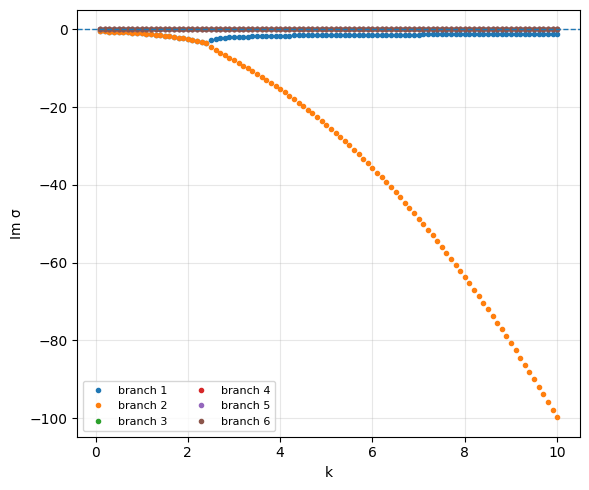

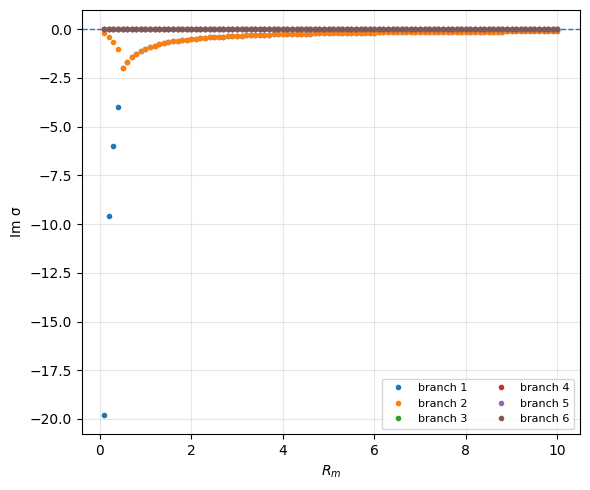

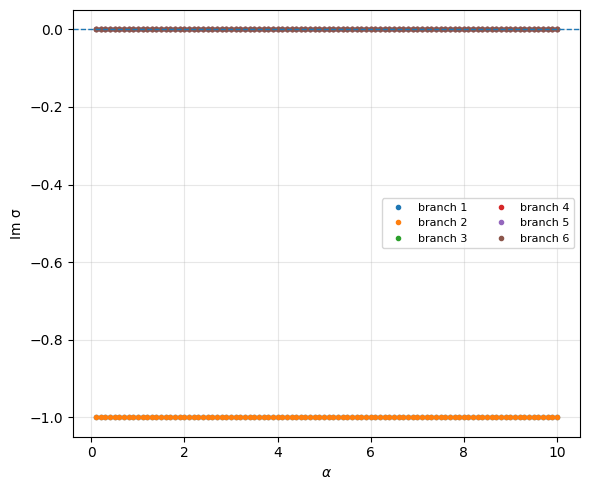

In [ ]:
if __name__ == "__main__":
    base = MHDParams(
        k=1.0,
        l=1.0,
        b0x=1.0,
        b0y=1.0,
        alpha=1.0,
        mu=1.0,
        rho=1.0,
        Rm=1.0,
        H0=1.0,
        g=9.8,
        Z0=1.0,
        p0=1.0,
        b0z_const=1.0,
        A_xi=1.0 + 0.0j,
        Bz_jump=0.0 + 0.0j,
        bz0_amp=0.0 + 0.0j,
    )

    roots_all, sigma_star, amps = analyze_case(base, backend="numpy", branch="max_imag")

    xs, br = sweep(base, "k", np.linspace(0.1, 10, 100), backend="numpy")
    plot_branches(xs, br, part="imag", xlabel="k")
    # plt.xscale("log")
    plt.show()

    xs, br = sweep(base, "Rm", np.linspace(0.1, 10, 100), backend="numpy")
    plot_branches(xs, br, part="imag", xlabel="$R_m$")
    # plt.xscale("log")
    plt.show()

    xs, br = sweep(base, "alpha", np.linspace(0.1, 10, 100), backend="numpy")
    plot_branches(xs, br, part="imag", xlabel=r"$\alpha$")
    # plt.xscale("log")
    plt.show()


## Дисперсионные кривые лдя $\tilde{B} \neq 0$

=== Исходные параметры ===
k            = 1.0
l            = 1.0
b0x          = 1.0
b0y          = 1.0
alpha        = 1.0
mu           = 1.0
rho          = 1.0
Rm           = 1.0
H0           = 1.0
g            = 9.8
Z0           = 1.0
p0           = 1.0
b0z_const    = 1.0
A_xi         = (1+0j)
Bz_jump      = (100+0j)
bz0_amp      = 0j

=== Производные параметры ===
omega = alpha/2          = 0.5
K2 = k^2 + l^2           = 2.0
K = sqrt(K2)             = 1.4142135623730951
M = b0x*k + b0y*l        = 2.0
mu*rho                   = 1.0
hB0 = H0 + Z0            = 2.0
|b0|^2                   = 3.0
M/sqrt(mu*rho)           = 2.0
K2/Rm                    = 2.0

P(sigma) degree = 6
sigma^ 6: +4.000000000000e+00 +0.000000000000e+00i
sigma^ 5: +0.000000000000e+00 +8.000000000000e+00i
sigma^ 4: -2.400000000000e+01 +0.000000000000e+00i
sigma^ 3: +0.000000000000e+00 -1.600000000000e+01i
sigma^ 2: +3.600000000000e+01 +0.000000000000e+00i
sigma^ 1: +0.000000000000e+00 +8.000000000000e+00i
sigma^ 0: 

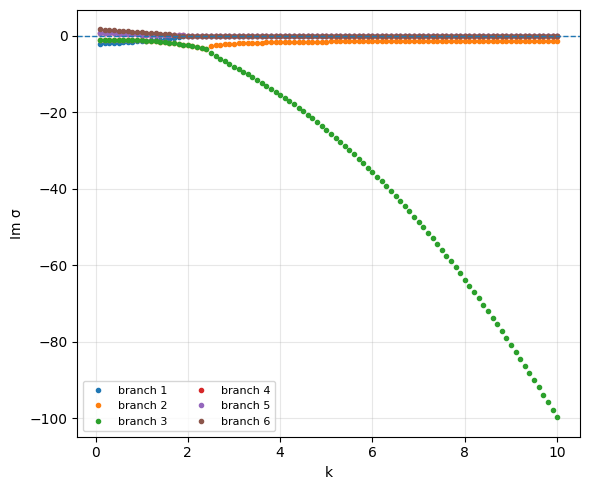

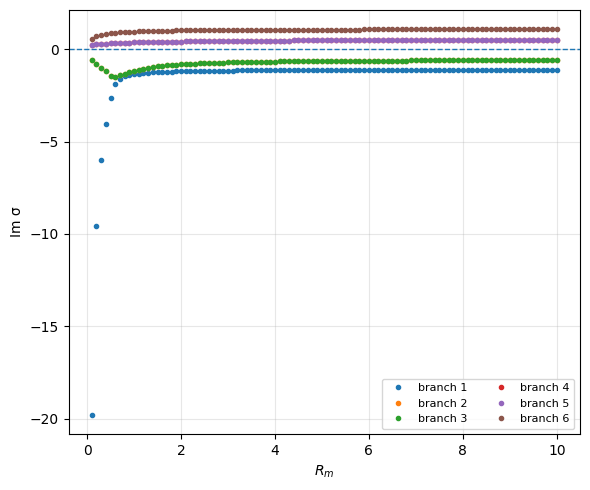

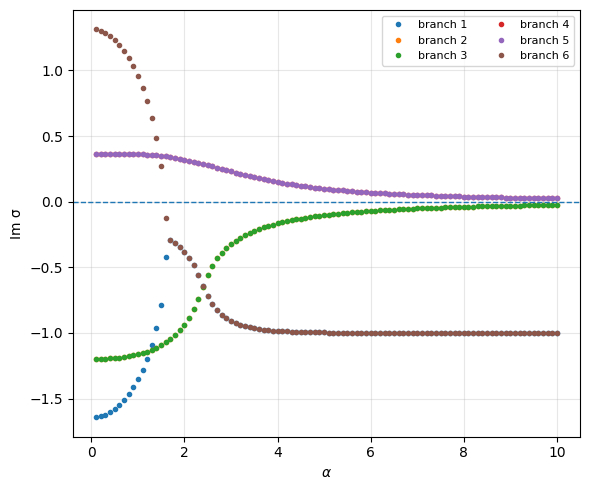

In [ ]:

# =============================================================================
# 9. Пример использования
# =============================================================================

if __name__ == "__main__":
    base = MHDParams(
        k=1.0,
        l=1.0,
        b0x=1.0,
        b0y=1.0,
        alpha=1.0,
        mu=1.0,
        rho=1.0,
        Rm=1.0,
        H0=1.0,
        g=9.8,
        Z0=1.0,
        p0=1.0,
        b0z_const=1.0,
        A_xi=1.0 + 0.0j,
        Bz_jump=100.0 + 0.0j,
        bz0_amp=0.0 + 0.0j,
    )

    roots_all, sigma_star, amps = analyze_case(base, backend="numpy", branch="max_imag")

    xs, br = sweep(base, "k", np.linspace(0.1, 10, 100), backend="numpy")
    plot_branches(xs, br, part="imag", xlabel="k")
    # plt.xscale("log")
    plt.show()

    xs, br = sweep(base, "Rm", np.linspace(0.1, 10, 100), backend="numpy")
    plot_branches(xs, br, part="imag", xlabel="$R_m$")
    # plt.xscale("log")
    plt.show()

    xs, br = sweep(base, "alpha", np.linspace(0.1, 10, 100), backend="numpy")
    plot_branches(xs, br, part="imag", xlabel=r"$\alpha$")
    # plt.xscale("log")
    plt.show()


Другие графики если нужны

=== Исходные параметры ===
k            = 1.0
l            = 1.0
b0x          = 1.0
b0y          = 1.0
alpha        = 1.0
mu           = 1.0
rho          = 1.0
Rm           = 1.0
H0           = 1.0
g            = 9.8
Z0           = 1.0
p0           = 1.0
b0z_const    = 1.0
A_xi         = (1+0j)
Bz_jump      = 0j
bz0_amp      = 0j

=== Производные параметры ===
omega = alpha/2          = 0.5
K2 = k^2 + l^2           = 2.0
K = sqrt(K2)             = 1.4142135623730951
M = b0x*k + b0y*l        = 2.0
mu*rho                   = 1.0
hB0 = H0 + Z0            = 2.0
|b0|^2                   = 3.0
M/sqrt(mu*rho)           = 2.0
K2/Rm                    = 2.0

P(sigma) degree = 6
sigma^ 6: +4.000000000000e+00 +0.000000000000e+00i
sigma^ 5: +0.000000000000e+00 +8.000000000000e+00i
sigma^ 4: -2.400000000000e+01 +0.000000000000e+00i
sigma^ 3: +0.000000000000e+00 -1.600000000000e+01i
sigma^ 2: +3.600000000000e+01 +0.000000000000e+00i
sigma^ 1: +0.000000000000e+00 +8.000000000000e+00i
sigma^ 0: -1.600

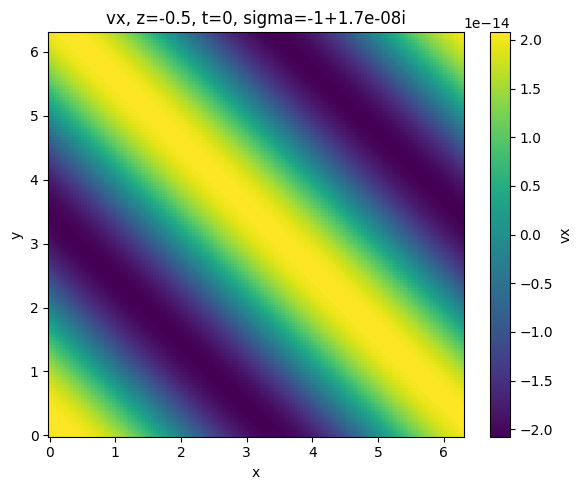

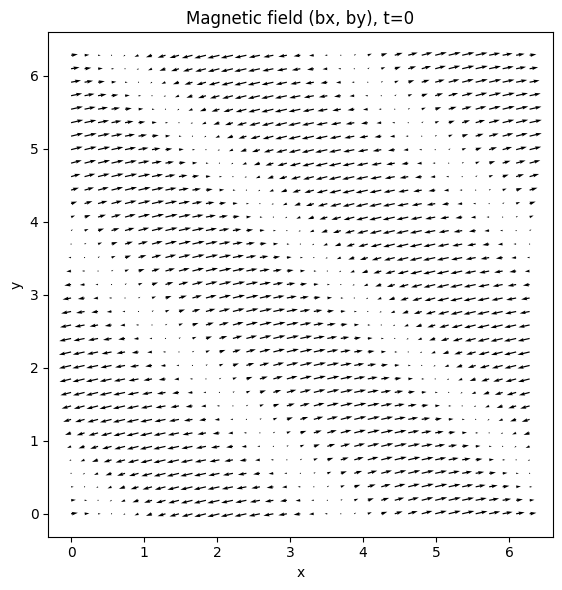

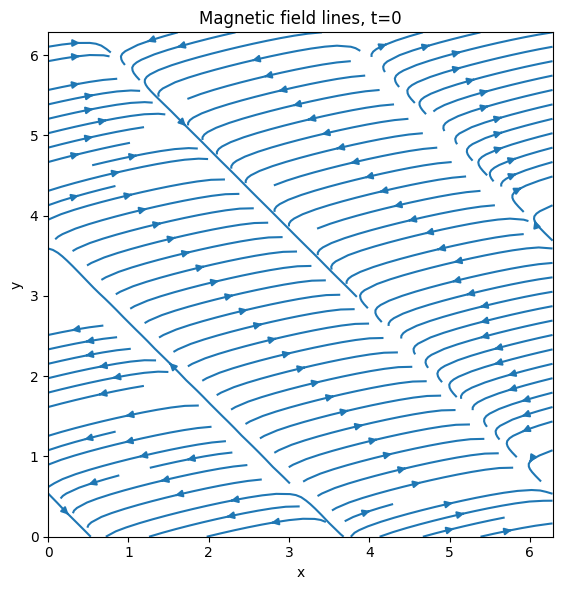

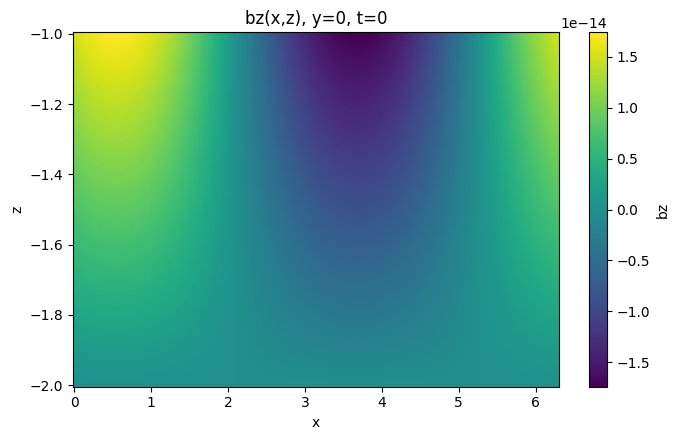

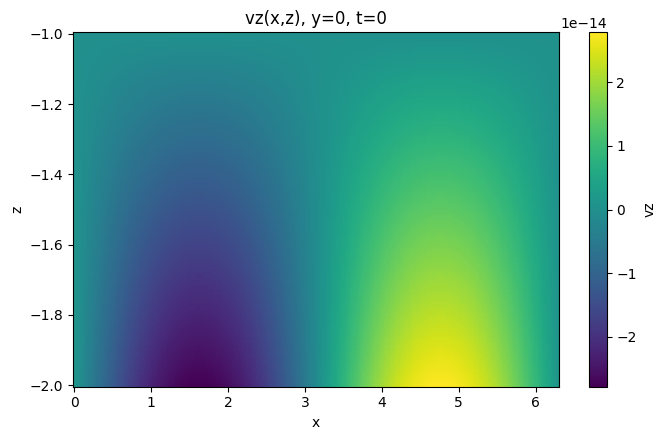

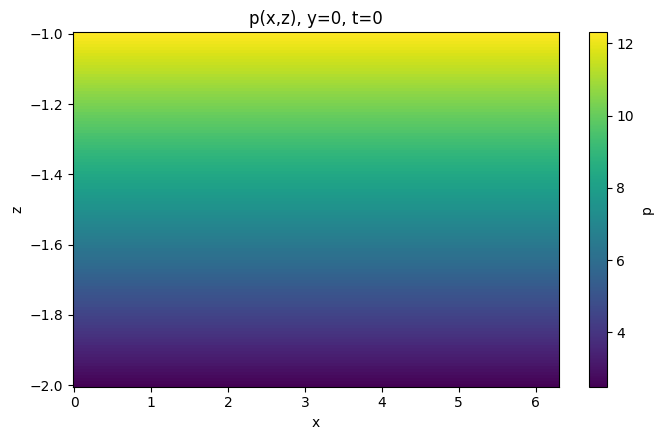

In [ ]:

# =============================================================================
# 9. Пример использования
# =============================================================================

if __name__ == "__main__":
    base = MHDParams(
        k=1.0,
        l=1.0,
        b0x=1.0,
        b0y=1.0,
        alpha=1.0,
        mu=1.0,
        rho=1.0,
        Rm=1.0,
        H0=1.0,
        g=9.8,
        Z0=1.0,
        p0=1.0,
        b0z_const=1.0,
        A_xi=1.0 + 0.0j,
        Bz_jump=0.0 + 0.0j,
        bz0_amp=0.0 + 0.0j,
    )

    roots_all, sigma_star, amps = analyze_case(base, backend="numpy", branch="max_imag")

    plot_field_snapshot(base, sigma_star, field="vx", z=-0.5, t=0.0)
    plt.show()

    plot_vector_field(base, sigma_star, vector="b", t=0.0, n=35)
    plt.show()

    plot_streamlines(base, sigma_star, vector="b", t=0.0)
    plt.show()

    plot_xz_slice(base, sigma_star, field="bz", y0=0.0, t=0.0)
    plt.show()

    plot_xz_slice(base, sigma_star, field="vz", y0=0.0, t=0.0)
    plt.show()

    plot_xz_slice(base, sigma_star, field="p", y0=0.0, t=0.0, pressure="full")
    plt.show()

# Случай непрерывности нормальной компоненты вектора магнитной индукции

## Визуализация критерия устойчивости

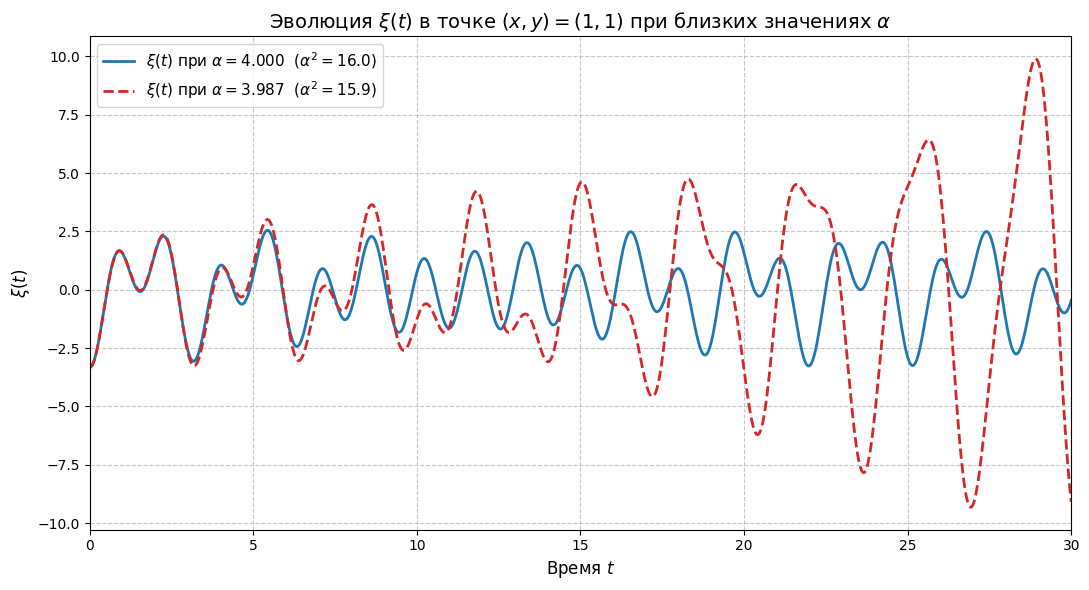

In [ ]:
if __name__ == "__main__":
    import sympy as sp
    import numpy as np
    import matplotlib.pyplot as plt

    # Символы
    A2, B2, alpha2, z = sp.symbols('A2 B2 alpha2 z')

    # Коэффициенты полинома
    a0 = 1
    a2 = -(A2 - alpha2 + 2 * B2)
    a4 = -A2 * B2 + B2**2
    polinom = a0 * z**4 + a2 * z**2 + a4

    # Общие параметры задачи
    k_ = 1.0
    l_ = 1.0
    x_ = 1.0
    y_ = 1.0
    mu_ = 1.0
    rho_ = 1.0
    g_ = 1.0
    H_0_ = 0.5
    b_0x_ = 2.0
    b_0y_ = 2.0

    # Вычисляем A и B
    A_val = g_ * H_0_ * (k_**2 + l_**2)
    B_val = (b_0x_ * k_ + b_0y_ * l_) / (mu_ * rho_)

    # Функция вычисления xi(t) при заданном alpha2_
    def compute_xi(alpha2_):
        params = {
            A2: g_ * H_0_ * (k_**2 + l_**2),
            B2: (b_0x_ * k_ + b_0y_ * l_) / (mu_ * rho_),
            alpha2: alpha2_
        }

        poly = sp.Poly(polinom.subs(params), z)
        roots = sp.nroots(poly, n=15)

        sigma = [1j * complex(r) for r in roots]
        alpha_val = np.sqrt(alpha2_)
        extra_sigmas = [alpha_val, alpha_val, -alpha_val, -alpha_val]
        sigma_total = sigma + extra_sigmas

        t_vals = np.linspace(0, 30, 800)
        xi_sum = np.zeros_like(t_vals, dtype=np.complex128)
        for s in sigma_total:
            s = complex(s)
            sigma1 = s.real
            sigma2 = s.imag
            xi_sum += A_val * np.exp(sigma2 * t_vals) * np.cos(k_ * x_ + l_ * y_ - sigma1 * t_vals)
        return t_vals, xi_sum.real

    # Вычисляем для alpha^2 = 16.0 и 15.9
    t16, xi16 = compute_xi(16.0)
    t159, xi159 = compute_xi(15.9)

    # Построение
    plt.figure(figsize=(11, 6))
    plt.plot(t16, xi16, label=r'$\xi(t)$ при $\alpha = 4.000$  ($\alpha^2 = 16.0$)', color='tab:blue', linewidth=2)
    plt.plot(t159, xi159, label=r'$\xi(t)$ при $\alpha = 3.987$  ($\alpha^2 = 15.9$)', color='tab:red', linewidth=2, linestyle='--')

    plt.title(r'Эволюция $\xi(t)$ в точке $(x,y) = (1,1)$ при близких значениях $\alpha$', fontsize=14)
    plt.xlabel('Время $t$', fontsize=12)
    plt.ylabel(r'$\xi(t)$', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(0, 30)
    plt.tight_layout()
    plt.show()

## Вспомогательные функции

In [ ]:
"""
MHD tools: случай непрерывности нормальной компоненты магнитного поля.

Модуль является аналогом блока для вертикальной компоненты, но использует
дисперсионное уравнение восьмой степени, возникающее при задании нормальной
компоненты магнитного поля на границах слоя.

Главная гармоника:
    xi(x,y,t) = A_xi * exp(i(kx + ly - sigma*t))

Замены операторов:
    Dt    -> -i*sigma,
    Delta -> -(k^2 + l^2),
    D     -> i*(b0x*k + b0y*l).

Важно:
1) Дисперсионное уравнение здесь другое: степень 8.
2) Горизонтальные поля bx, by, vx, vy восстанавливаются тем же операторным
   способом, что и в теореме восстановления.
3) Вертикальная компонента bz для нормального условия удобнее считать через
   нормальное граничное условие. В линейном приближении она сводится к
       bz = -(hB0 + z) * div_h(b) + Bn0.
   Если нужно увидеть слабонелинейную геометрию поверхности, можно включить
   include_nonlinear_geometry=True.
4) p0 и b0_pressure_abs2 могут быть числами или функциями p0(x,y,t), b0^2(x,y,t).
"""

from __future__ import annotations

from dataclasses import dataclass, replace, asdict
from typing import Callable, Iterable, Literal, Any
import subprocess
import numpy as np
import matplotlib.pyplot as plt

ArrayLike = Iterable[float]
RootBackend = Literal["numpy", "newton"]
FieldPart = Literal["real", "imag"]
VectorKind = Literal["b", "v"]
PressureMode = Literal["linear", "full", "total"]
ScalarField = float | complex | Callable[[Any, Any, float], Any]


# =============================================================================
# 1. Параметры задачи
# =============================================================================

@dataclass(frozen=True)
class MHDNormalParams:
    """
    Параметры для случая непрерывности нормальной компоненты магнитного поля.

    B_normal
        Амплитуда правой части в дисперсионном уравнении нормальной задачи.
        В старом коде это Bbig.

    Bn0_amp
        Амплитуда гармоники нормальной компоненты на свободной поверхности.
        Нужна для восстановления bz, но не обязана совпадать с B_normal.

    p0
        Либо число, либо функция p0(x,y,t).

    b0_pressure_abs2
        Либо число |b0|^2, либо функция |b0(x,y,t)|^2.
        Если None, используется b0x^2 + b0y^2 + b0z_const^2.
    """

    # волновые числа
    k: float = 1.0
    l: float = 1.0

    # фоновое горизонтальное магнитное поле
    b0x: float = 1.0
    b0y: float = 1.0

    # физические параметры
    alpha: float = 1.0
    mu: float = 1.0
    rho: float = 1.0
    Rm: float = 1.0
    H0: float = 1.0
    g: float = 9.8

    # геометрия слоя: твердая граница z=-Z0, свободная z=-hB0
    Z0: float = 0.0

    # давление и магнитное давление на границе: числа или функции x,y,t
    p0: ScalarField = 0.0
    b0z_const: float = 0.0
    b0_pressure_abs2: ScalarField | None = None

    # амплитуды гармоник
    A_xi: complex = 1.0 + 0.0j
    B_normal: complex = 0.0 + 0.0j
    Bn0_amp: complex = 0.0 + 0.0j

    @property
    def omega(self) -> float:
        return self.alpha / 2.0

    @property
    def K2(self) -> float:
        return self.k**2 + self.l**2

    @property
    def K(self) -> float:
        return float(np.sqrt(self.K2))

    @property
    def M(self) -> float:
        return self.b0x * self.k + self.b0y * self.l

    @property
    def murho(self) -> float:
        return self.mu * self.rho

    @property
    def hB0(self) -> float:
        """Невозмущенное положение свободной поверхности: z=-hB0."""
        return self.H0 + self.Z0

    @property
    def alfven_frequency_ideal(self) -> float:
        return self.M / float(np.sqrt(self.murho))

    @property
    def diffusion_rate(self) -> float:
        return self.K2 / self.Rm

    @property
    def default_b0_abs2(self) -> float:
        return self.b0x**2 + self.b0y**2 + self.b0z_const**2

    def with_(self, **kwargs) -> "MHDNormalParams":
        return replace(self, **kwargs)

    def as_dict(self) -> dict:
        return asdict(self)

    def derived_dict(self) -> dict:
        return {
            "omega = alpha/2": self.omega,
            "K2 = k^2 + l^2": self.K2,
            "K = sqrt(K2)": self.K,
            "M = b0x*k + b0y*l": self.M,
            "mu*rho": self.murho,
            "hB0 = H0 + Z0": self.hB0,
            "default |b0|^2": self.default_b0_abs2,
            "M/sqrt(mu*rho)": self.alfven_frequency_ideal,
            "K2/Rm": self.diffusion_rate,
        }

    def print_report(self) -> None:
        print("=== Исходные параметры: normal-field case ===")
        for key, value in self.as_dict().items():
            if callable(value):
                value = f"<function {getattr(value, '__name__', 'lambda')}>"
            print(f"{key:18s} = {value}")

        print("\n=== Производные параметры ===")
        for key, value in self.derived_dict().items():
            print(f"{key:28s} = {value}")


# =============================================================================
# 2. Дисперсионное уравнение восьмой степени
# =============================================================================

def normal_dispersion_poly(p: MHDNormalParams) -> np.poly1d:
    """
    Дисперсионный полином для случая нормальной компоненты поля.

    Используется компактная запись:
        K2 = k^2 + l^2,
        M  = b0x*k + b0y*l,
        Q  = -i*sigma + K2/Rm.

    Уравнение:

    - M (sigma^2-alpha^2)^2
      [-sigma^2 + M^2/(mu*rho) - i*sigma*K2/Rm] K2

    + M/(g*(mu*rho)^2*H0) (alpha^2-sigma^2)^2
      [ (mu*rho)^2 (alpha^2-sigma^2) Q^2
        + M^4
        + 2 i mu rho sigma Q M^2 ]

    + i*B_normal/(A_xi*(mu*rho)^2*H0) = 0.

    Это форма восьмой степени, соответствующая нормальному магнитному условию
    при постоянных H0 и Z0.
    """
    s = np.poly1d([1.0, 0.0])
    K2 = p.K2
    M = p.M
    murho = p.murho

    Q = -1j * s + K2 / p.Rm
    inertial_minus = s**2 - p.alpha**2
    inertial_plus = p.alpha**2 - s**2

    first = -M * inertial_minus**2 * (
        -s**2 + M**2 / murho - 1j * s * K2 / p.Rm
    ) * K2

    bracket = (
        murho**2 * inertial_plus * Q**2
        + M**4
        + 2j * murho * s * Q * M**2
    )

    second = M / (p.g * murho**2 * p.H0) * inertial_plus**2 * bracket

    forcing = 1j * p.B_normal / (p.A_xi * murho**2 * p.H0)

    return first + second + forcing


def normal_dispersion_poly_old_user_formula(p: MHDNormalParams) -> np.poly1d:
    """
    Вариант, максимально близкий к твоему старому SymPy expr_n8.
    Оставлен для проверки старых графиков. Для диплома лучше использовать
    normal_dispersion_poly(), если формула в тексте записана как в статье/дипломе.
    """
    s = np.poly1d([1.0, 0.0])
    K2 = p.K2
    M = p.M
    murho = p.murho

    first = -M * (s**2 - p.alpha**2)**2 * (
        -s**2 - 1j * s * K2 / p.Rm + M**2 / murho
    ) * K2

    second = (
        1.0 / (p.g * murho**2 * p.H0)
        * (p.alpha**2 - s**2)
        * (
            murho**2 * (s**2 - p.alpha**2)**2 * (-1j * s + K2 / p.Rm)**2
            - M**4 * (s**2 - p.alpha**2)
            + 2j * murho * s * (p.alpha**2 - s**2) * (-1j * s + K2 / p.Rm) * M**2
        )
        * M
    )

    forcing = 1j * p.B_normal / (p.A_xi * murho**2 * p.H0)
    return first + second + forcing


def poly_coefficients(poly: np.poly1d, trim_tol: float = 1e-12) -> np.ndarray:
    coeffs = np.asarray(poly.c, dtype=complex)
    while len(coeffs) > 1 and abs(coeffs[0]) < trim_tol:
        coeffs = coeffs[1:]
    return coeffs


def dispersion_coefficients(p: MHDNormalParams, use_old_formula: bool = False) -> np.ndarray:
    poly = normal_dispersion_poly_old_user_formula(p) if use_old_formula else normal_dispersion_poly(p)
    return poly_coefficients(poly)


def print_dispersion_polynomial(p: MHDNormalParams, use_old_formula: bool = False) -> None:
    coeffs = dispersion_coefficients(p, use_old_formula=use_old_formula)
    degree = len(coeffs) - 1
    print(f"P(sigma) degree = {degree}")
    for i, c in enumerate(coeffs):
        power = degree - i
        print(f"sigma^{power:2d}: {c.real:+.12e} {c.imag:+.12e}i")


# =============================================================================
# 3. Корни
# =============================================================================

def roots_numpy(p: MHDNormalParams, use_old_formula: bool = False) -> np.ndarray:
    return np.roots(dispersion_coefficients(p, use_old_formula=use_old_formula))


def roots_newton_cpp(
    p: MHDNormalParams,
    executable: str = "./newton",
    use_old_formula: bool = False,
) -> np.ndarray:
    coeffs = dispersion_coefficients(p, use_old_formula=use_old_formula)
    input_data = f"{p.Rm}\n" + "\n".join(
        f"{c.real:.17g} {c.imag:.17g}" for c in coeffs
    ) + "\n"

    result = subprocess.run(
        [executable],
        input=input_data,
        text=True,
        capture_output=True,
        check=False,
    )

    if result.returncode != 0:
        raise RuntimeError(
            f"newton завершился с кодом {result.returncode}\n"
            f"stderr:\n{result.stderr}\nstdout:\n{result.stdout}"
        )

    lines = [line.strip() for line in result.stdout.splitlines() if line.strip()]
    if not lines:
        return np.array([], dtype=complex)

    out = []
    for line in lines[1:]:
        parts = line.split()
        if len(parts) >= 2:
            out.append(float(parts[0]) + 1j * float(parts[1]))
    return np.asarray(out, dtype=complex)


def roots(
    p: MHDNormalParams,
    backend: RootBackend = "numpy",
    use_old_formula: bool = False,
) -> np.ndarray:
    if backend == "numpy":
        return roots_numpy(p, use_old_formula=use_old_formula)
    if backend == "newton":
        return roots_newton_cpp(p, use_old_formula=use_old_formula)
    raise ValueError(f"unknown backend: {backend}")


def sort_roots_single(roots_array: np.ndarray) -> np.ndarray:
    return np.asarray(sorted(roots_array, key=lambda z: (z.imag, z.real)))


def print_roots(
    p: MHDNormalParams,
    backend: RootBackend = "numpy",
    use_old_formula: bool = False,
) -> np.ndarray:
    r = sort_roots_single(roots(p, backend=backend, use_old_formula=use_old_formula))
    print("=== Корни sigma ===")
    for j, z in enumerate(r, start=1):
        if z.imag > 1e-10:
            stability = "рост"
        elif z.imag < -1e-10:
            stability = "затухание"
        else:
            stability = "периодический"
        print(f"{j:2d}: sigma = {z.real:+.10e} {z.imag:+.10e}i   ({stability})")
    return r


# =============================================================================
# 4. Параметрические проходы и ветви
# =============================================================================

def match_roots_by_continuation(prev: np.ndarray, cur: np.ndarray) -> np.ndarray:
    prev = np.asarray(prev)
    cur = list(np.asarray(cur))
    matched = []
    for z in prev:
        j = int(np.argmin([abs(w - z) for w in cur]))
        matched.append(cur.pop(j))
    return np.asarray(matched, dtype=complex)


def sweep(
    base: MHDNormalParams,
    name: str,
    values: ArrayLike,
    backend: RootBackend = "numpy",
    use_old_formula: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    xs = np.asarray(list(values), dtype=float)
    branches = []

    for idx, value in enumerate(xs):
        p = base.with_(**{name: float(value)})
        r = roots(p, backend=backend, use_old_formula=use_old_formula)
        r = sort_roots_single(r) if idx == 0 else match_roots_by_continuation(branches[-1], r)
        branches.append(r)

    return xs, np.vstack(branches)


def plot_branches(
    xs: np.ndarray,
    branches: np.ndarray,
    part: FieldPart = "imag",
    xlabel: str = "parameter",
):
    y = branches.real if part == "real" else branches.imag
    ylabel = "Re σ" if part == "real" else "Im σ"

    fig, ax = plt.subplots(figsize=(6, 5))
    for j in range(y.shape[1]):
        ax.plot(xs, y[:, j], ".", lw=1.5, label=f"branch {j+1}")
    ax.axhline(0.0, lw=1.0, ls="--")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()
    return fig, ax


def plot_comparison_B0_Bnonzero(
    base: MHDNormalParams,
    name: str,
    values: ArrayLike,
    B_nonzero: complex = 100.0 + 0.0j,
    backend: RootBackend = "numpy",
    use_old_formula: bool = False,
):
    p0 = base.with_(B_normal=0.0 + 0.0j)
    pB = base.with_(B_normal=B_nonzero)

    xs0, br0 = sweep(p0, name, values, backend=backend, use_old_formula=use_old_formula)
    xsB, brB = sweep(pB, name, values, backend=backend, use_old_formula=use_old_formula)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

    for j in range(br0.shape[1]):
        axes[0].scatter(xs0, br0[:, j].imag, s=10, alpha=0.75, label=f"branch {j+1}")
    axes[0].axhline(0.0, lw=1.0, ls="--")
    axes[0].set_title("B=0")
    axes[0].set_xlabel(name)
    axes[0].set_ylabel("Im σ")
    axes[0].grid(True, alpha=0.3)

    for j in range(brB.shape[1]):
        axes[1].scatter(xsB, brB[:, j].imag, s=10, alpha=0.75, label=f"branch {j+1}")
    axes[1].axhline(0.0, lw=1.0, ls="--")
    axes[1].set_title("B≠0")
    axes[1].set_xlabel(name)
    axes[1].grid(True, alpha=0.3)

    axes[1].legend(ncol=2, fontsize=8)
    fig.tight_layout()
    return fig, axes


# =============================================================================
# 5. Амплитуды и восстановление горизонтальных полей
# =============================================================================

def sigma_multiplier(p: MHDNormalParams, sigma: complex) -> dict[str, complex]:
    Dt = -1j * sigma
    Delta = -p.K2
    D = 1j * p.M
    F = p.murho * (Dt**2 + p.alpha**2) * (Dt - Delta / p.Rm) - D**2 * Dt
    return {"Dt": Dt, "Delta": Delta, "D": D, "F": F}


def mode_fields_amplitudes(p: MHDNormalParams, sigma: complex) -> dict[str, complex]:
    """
    Комплексные амплитуды горизонтальных возмущений для одной моды.

    Эта часть совпадает с операторным восстановлением из теоремы:
        bx, by, vx, vy, eta
    считаются через xi и найденную sigma.

    Реальное поле:
        field(x,y,t) = Re(field_amp * exp(i(kx+ly-sigma*t))).
    """
    m = sigma_multiplier(p, sigma)
    Dt, D, Delta, F = m["Dt"], m["D"], m["Delta"], m["F"]
    A = p.A_xi

    xi_x = 1j * p.k * A
    xi_y = 1j * p.l * A

    Q = Dt - Delta / p.Rm
    L = p.murho * Dt * Q - D**2
    C = p.alpha * p.murho * Q
    common = D * (Dt**2 + p.alpha**2)

    bxtilde_t = common * (L * xi_x + C * xi_y)
    bytilde_t = common * (-C * xi_x + L * xi_y)

    bx = p.murho * (Dt**2 + p.alpha**2) * bxtilde_t
    by = p.murho * (Dt**2 + p.alpha**2) * bytilde_t

    eta_tilde_t = (F**2 + (p.alpha * D**2)**2) * A
    eta = -(1.0 / p.g) * (Dt**2 + p.alpha**2) * eta_tilde_t

    vx = Dt * (1j * p.k * eta_tilde_t + D * bxtilde_t) + p.alpha * (
        1j * p.l * eta_tilde_t + D * bytilde_t
    )
    vy = -p.alpha * (1j * p.k * eta_tilde_t + D * bxtilde_t) + Dt * (
        1j * p.l * eta_tilde_t + D * bytilde_t
    )

    div_b = 1j * p.k * bx + 1j * p.l * by
    div_v = 1j * p.k * vx + 1j * p.l * vy
    eta_x = 1j * p.k * eta
    eta_y = 1j * p.l * eta

    return {
        "xi": A,
        "bx": bx,
        "by": by,
        "eta": eta,
        "vx": vx,
        "vy": vy,
        "div_b": div_b,
        "div_v": div_v,
        "eta_x": eta_x,
        "eta_y": eta_y,
    }


def print_amplitudes(p: MHDNormalParams, sigma: complex) -> dict[str, complex]:
    amps = mode_fields_amplitudes(p, sigma)
    print("=== Амплитуды моды ===")
    print(f"sigma = {sigma.real:+.10e} {sigma.imag:+.10e}i")
    for name, value in amps.items():
        print(f"{name:8s} = {value.real:+.10e} {value.imag:+.10e}i")
    return amps


def real_formula_from_amplitude(
    field_name: str,
    amplitude: complex,
    p: MHDNormalParams,
    sigma: complex,
    digits: int = 6,
) -> str:
    a = amplitude.real
    b = amplitude.imag
    sigma1 = sigma.real
    sigma2 = sigma.imag
    return (
        f"{field_name}(x,y,t) = exp(({sigma2:.{digits}g}) t) * "
        f"(({a:.{digits}g}) cos({p.k:.{digits}g} x + {p.l:.{digits}g} y - ({sigma1:.{digits}g}) t) "
        f"- ({b:.{digits}g}) sin({p.k:.{digits}g} x + {p.l:.{digits}g} y - ({sigma1:.{digits}g}) t))"
    )


def print_real_formulas(
    p: MHDNormalParams,
    sigma: complex,
    fields: tuple[str, ...] = ("bx", "by", "vx", "vy", "eta"),
) -> None:
    amps = mode_fields_amplitudes(p, sigma)
    print("=== Вещественные выражения для одной моды ===")
    for field in fields:
        print(real_formula_from_amplitude(field, amps[field], p, sigma))


# =============================================================================
# 6. Значения полей и функции p0(x,y,t), b0^2(x,y,t)
# =============================================================================

def eval_scalar_field(field: ScalarField | None, x, y, t: float, default=0.0):
    if field is None:
        return default
    if callable(field):
        return field(x, y, t)
    return field


def phase_factor(p: MHDNormalParams, sigma: complex, x, y, t: float):
    return np.exp(1j * (p.k * x + p.l * y - sigma * t))


def real_mode_value(amplitude: complex, p: MHDNormalParams, sigma: complex, x, y, t: float):
    return np.real(amplitude * phase_factor(p, sigma, x, y, t))


def evaluate_horizontal_field(
    p: MHDNormalParams,
    sigma: complex,
    field: str,
    x,
    y,
    t: float = 0.0,
):
    amps = mode_fields_amplitudes(p, sigma)
    if field not in amps:
        raise KeyError(f"field must be one of {list(amps)}")
    return np.real(amps[field] * phase_factor(p, sigma, x, y, t))


def make_xy_grid(
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    ylim: tuple[float, float] = (0.0, 2 * np.pi),
    n: int = 100,
) -> tuple[np.ndarray, np.ndarray]:
    xs = np.linspace(*xlim, n)
    ys = np.linspace(*ylim, n)
    return np.meshgrid(xs, ys)


def hB_value(
    p: MHDNormalParams,
    sigma: complex,
    x,
    y,
    t: float = 0.0,
    include_eta: bool = False,
):
    if not include_eta:
        return p.hB0
    return p.hB0 + evaluate_horizontal_field(p, sigma, "eta", x, y, t=t)


# =============================================================================
# 7. bz, vz, давление
# =============================================================================

def Bn0_value(
    p: MHDNormalParams,
    sigma: complex,
    x,
    y,
    t: float = 0.0,
):
    """Нормальная компонента на свободной поверхности как гармоника."""
    return np.real(p.Bn0_amp * phase_factor(p, sigma, x, y, t))


def bz_value(
    p: MHDNormalParams,
    sigma: complex,
    x,
    y,
    z,
    t: float = 0.0,
    include_nonlinear_geometry: bool = False,
):
    """
    Вертикальная компонента магнитного поля для нормального магнитного условия.

    Линейный вариант:
        bz = -(hB0 + z) * div_h(b) + Bn0.

    Слабонелинейная геометрическая визуализация:
        bz = -(hB0 + eta + z) div_h(b)
             - bx*eta_x - by*eta_y
             + Bn0*sqrt(1 + eta_x^2 + eta_y^2).

    Для строгого линейного анализа в дипломе обычно использовать
        include_nonlinear_geometry=False.
    """
    amps = mode_fields_amplitudes(p, sigma)
    phase = phase_factor(p, sigma, x, y, t)

    div_b = np.real(amps["div_b"] * phase)
    Bn0 = Bn0_value(p, sigma, x, y, t=t)

    if not include_nonlinear_geometry:
        return -(p.hB0 + z) * div_b + Bn0

    bx = np.real(amps["bx"] * phase)
    by = np.real(amps["by"] * phase)
    eta = np.real(amps["eta"] * phase)
    eta_x = np.real(amps["eta_x"] * phase)
    eta_y = np.real(amps["eta_y"] * phase)

    return (
        -(p.hB0 + eta + z) * div_b
        - bx * eta_x
        - by * eta_y
        + Bn0 * np.sqrt(1.0 + eta_x**2 + eta_y**2)
    )


def vz_value(
    p: MHDNormalParams,
    sigma: complex,
    x,
    y,
    z,
    t: float = 0.0,
):
    """Для плоского дна Z=Z0: vz = -(Z0+z) div_h(v)."""
    amps = mode_fields_amplitudes(p, sigma)
    phase = phase_factor(p, sigma, x, y, t)
    div_v = np.real(amps["div_v"] * phase)
    return -(p.Z0 + z) * div_v


def total_hydromagnetic_pressure_value(
    p: MHDNormalParams,
    sigma: complex,
    x,
    y,
    z,
    t: float = 0.0,
    include_eta_in_hB: bool = False,
):
    """
    p + b^2/(2mu) = p0(x,y,t) + b0^2(x,y,t)/(2mu) + rho*g*(hB+z).
    """
    p0_val = eval_scalar_field(p.p0, x, y, t, default=0.0)
    b0_abs2_val = eval_scalar_field(
        p.b0_pressure_abs2, x, y, t, default=p.default_b0_abs2
    )
    h = hB_value(p, sigma, x, y, t=t, include_eta=include_eta_in_hB)
    return p0_val + b0_abs2_val / (2.0 * p.mu) + p.rho * p.g * (h + z)


def magnetic_pressure_value(bx, by, bz, p: MHDNormalParams):
    return (bx**2 + by**2 + bz**2) / (2.0 * p.mu)


def pressure_value(
    p: MHDNormalParams,
    sigma: complex,
    x,
    y,
    z,
    t: float = 0.0,
    mode: PressureMode = "linear",
    include_eta_in_hB: bool = False,
    include_nonlinear_bz_geometry: bool = False,
):
    total = total_hydromagnetic_pressure_value(
        p, sigma, x, y, z, t=t, include_eta_in_hB=include_eta_in_hB
    )

    if mode == "total":
        return total
    if mode == "linear":
        return total
    if mode == "full":
        bx = evaluate_horizontal_field(p, sigma, "bx", x, y, t=t)
        by = evaluate_horizontal_field(p, sigma, "by", x, y, t=t)
        bz = bz_value(
            p, sigma, x, y, z, t=t,
            include_nonlinear_geometry=include_nonlinear_bz_geometry,
        )
        return total - magnetic_pressure_value(bx, by, bz, p)

    raise ValueError("mode must be 'linear', 'full' or 'total'")


def fields_on_grid(
    p: MHDNormalParams,
    sigma: complex,
    x_grid: np.ndarray,
    y_grid: np.ndarray,
    z: float = 0.0,
    t: float = 0.0,
    pressure: PressureMode = "linear",
) -> dict[str, np.ndarray]:
    out = {}
    for field in ("xi", "bx", "by", "vx", "vy", "eta", "div_b", "div_v", "eta_x", "eta_y"):
        out[field] = evaluate_horizontal_field(p, sigma, field, x_grid, y_grid, t=t)
    out["bz"] = bz_value(p, sigma, x_grid, y_grid, z=z, t=t)
    out["vz"] = vz_value(p, sigma, x_grid, y_grid, z=z, t=t)
    out["p"] = pressure_value(p, sigma, x_grid, y_grid, z=z, t=t, mode=pressure)
    return out


# =============================================================================
# 8. Графики
# =============================================================================

def plot_field_snapshot(
    p: MHDNormalParams,
    sigma: complex,
    field: str = "bx",
    z: float = 0.0,
    t: float = 0.0,
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    ylim: tuple[float, float] = (0.0, 2 * np.pi),
    n: int = 150,
    pressure: PressureMode = "linear",
):
    X, Y = make_xy_grid(xlim, ylim, n)

    if field == "bz":
        Z = bz_value(p, sigma, X, Y, z=z, t=t)
    elif field == "vz":
        Z = vz_value(p, sigma, X, Y, z=z, t=t)
    elif field == "p":
        Z = pressure_value(p, sigma, X, Y, z=z, t=t, mode=pressure)
    else:
        Z = evaluate_horizontal_field(p, sigma, field, X, Y, t=t)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.pcolormesh(X, Y, Z, shading="auto")
    fig.colorbar(im, ax=ax, label=field)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{field}, z={z:g}, t={t:g}, sigma={sigma.real:.3g}{sigma.imag:+.3g}i")
    fig.tight_layout()
    return fig, ax


def plot_vector_field(
    p: MHDNormalParams,
    sigma: complex,
    vector: VectorKind = "b",
    t: float = 0.0,
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    ylim: tuple[float, float] = (0.0, 2 * np.pi),
    n: int = 35,
    normalize: bool = False,
):
    X, Y = make_xy_grid(xlim, ylim, n)

    if vector == "b":
        U = evaluate_horizontal_field(p, sigma, "bx", X, Y, t=t)
        V = evaluate_horizontal_field(p, sigma, "by", X, Y, t=t)
        title = "Magnetic field (bx, by), normal condition"
    elif vector == "v":
        U = evaluate_horizontal_field(p, sigma, "vx", X, Y, t=t)
        V = evaluate_horizontal_field(p, sigma, "vy", X, Y, t=t)
        title = "Velocity field (vx, vy), normal condition"
    else:
        raise ValueError("vector must be 'b' or 'v'")

    if normalize:
        norm = np.sqrt(U**2 + V**2)
        U = np.divide(U, norm, out=np.zeros_like(U), where=norm > 1e-14)
        V = np.divide(V, norm, out=np.zeros_like(V), where=norm > 1e-14)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.quiver(X, Y, U, V)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{title}, t={t:g}")
    ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    return fig, ax


def plot_streamlines(
    p: MHDNormalParams,
    sigma: complex,
    vector: VectorKind = "b",
    t: float = 0.0,
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    ylim: tuple[float, float] = (0.0, 2 * np.pi),
    n: int = 100,
    density: float = 1.2,
):
    X, Y = make_xy_grid(xlim, ylim, n)

    if vector == "b":
        U = evaluate_horizontal_field(p, sigma, "bx", X, Y, t=t)
        V = evaluate_horizontal_field(p, sigma, "by", X, Y, t=t)
        title = "Magnetic field lines, normal condition"
    elif vector == "v":
        U = evaluate_horizontal_field(p, sigma, "vx", X, Y, t=t)
        V = evaluate_horizontal_field(p, sigma, "vy", X, Y, t=t)
        title = "Velocity streamlines, normal condition"
    else:
        raise ValueError("vector must be 'b' or 'v'")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.streamplot(X, Y, U, V, density=density)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{title}, t={t:g}")
    ax.set_aspect("equal", adjustable="box")
    fig.tight_layout()
    return fig, ax


def plot_xz_slice(
    p: MHDNormalParams,
    sigma: complex,
    field: Literal["bz", "vz", "p"] = "bz",
    y0: float = 0.0,
    t: float = 0.0,
    zlim: tuple[float, float] | None = None,
    xlim: tuple[float, float] = (0.0, 2 * np.pi),
    nx: int = 220,
    nz: int = 120,
    pressure: PressureMode = "linear",
):
    if zlim is None:
        zlim = (-p.hB0, -p.Z0)

    xs = np.linspace(*xlim, nx)
    zs = np.linspace(*zlim, nz)
    X, Z = np.meshgrid(xs, zs)
    Y = np.full_like(X, y0)

    if field == "bz":
        V = bz_value(p, sigma, X, Y, Z, t=t)
    elif field == "vz":
        V = vz_value(p, sigma, X, Y, Z, t=t)
    elif field == "p":
        V = pressure_value(p, sigma, X, Y, Z, t=t, mode=pressure)
    else:
        raise ValueError("field must be 'bz', 'vz' or 'p'")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    im = ax.pcolormesh(X, Z, V, shading="auto")
    fig.colorbar(im, ax=ax, label=field)
    ax.set_xlabel("x")
    ax.set_ylabel("z")
    ax.set_title(f"{field}(x,z), y={y0:g}, t={t:g}")
    fig.tight_layout()
    return fig, ax


def plot_phase_trajectory(
    p: MHDNormalParams,
    sigma: complex,
    field_x: str = "bx",
    field_y: str = "by",
    point: tuple[float, float] = (1.0, 1.0),
    tlim: tuple[float, float] = (0.0, 30.0),
    n: int = 1000,
):
    x0, y0 = point
    ts = np.linspace(*tlim, n)
    amps = mode_fields_amplitudes(p, sigma)
    Xv = np.array([real_mode_value(amps[field_x], p, sigma, x0, y0, t) for t in ts])
    Yv = np.array([real_mode_value(amps[field_y], p, sigma, x0, y0, t) for t in ts])

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(Xv, Yv)
    ax.set_xlabel(field_x)
    ax.set_ylabel(field_y)
    ax.set_title(f"Phase trajectory at (x,y)=({x0:g},{y0:g})")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig, ax

def select_branch(r: np.ndarray, branch: Literal["max_imag", "min_imag", "first"] | int) -> complex:
    if isinstance(branch, int):
        return r[branch]
    if branch == "max_imag":
        return r[int(np.argmax(r.imag))]
    if branch == "min_imag":
        return r[int(np.argmin(r.imag))]
    if branch == "first":
        return r[0]
    raise ValueError("unknown branch")


def analyze_case(
    p: MHDNormalParams,
    backend: RootBackend = "numpy",
    branch: Literal["max_imag", "min_imag", "first"] | int = "max_imag",
    use_old_formula: bool = False,
) -> tuple[np.ndarray, complex, dict[str, complex]]:
    p.print_report()
    print()
    print_dispersion_polynomial(p, use_old_formula=use_old_formula)
    print()
    r = print_roots(p, backend=backend, use_old_formula=use_old_formula)

    sigma = select_branch(r, branch)

    print(f"\n=== Выбранная ветвь ===\nsigma = {sigma.real:+.10e} {sigma.imag:+.10e}i")
    amps = print_amplitudes(p, sigma)
    print()
    print_real_formulas(p, sigma)
    return r, sigma, amps

## Дисперсионные кривые для $\tilde{B} = 0$

=== Исходные параметры: normal-field case ===
k                  = 1.0
l                  = 1.0
b0x                = 1.0
b0y                = 1.0
alpha              = 1.0
mu                 = 1.0
rho                = 1.0
Rm                 = 1.0
H0                 = 1.0
g                  = 9.8
Z0                 = 1.0
p0                 = 1.0
b0z_const          = 1.0
b0_pressure_abs2   = None
A_xi               = (1+0j)
B_normal           = 0j
Bn0_amp            = 0j

=== Производные параметры ===
omega = alpha/2              = 0.5
K2 = k^2 + l^2               = 2.0
K = sqrt(K2)                 = 1.4142135623730951
M = b0x*k + b0y*l            = 2.0
mu*rho                       = 1.0
hB0 = H0 + Z0                = 2.0
default |b0|^2               = 3.0
M/sqrt(mu*rho)               = 2.0
K2/Rm                        = 2.0

P(sigma) degree = 8
sigma^ 8: +2.040816326531e-01 +0.000000000000e+00i
sigma^ 7: +0.000000000000e+00 +8.163265306122e-01i
sigma^ 6: +4.204081632653e+00 +0.0000000000

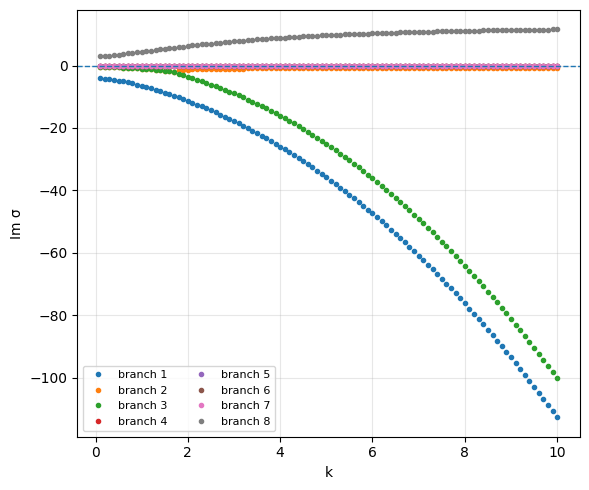

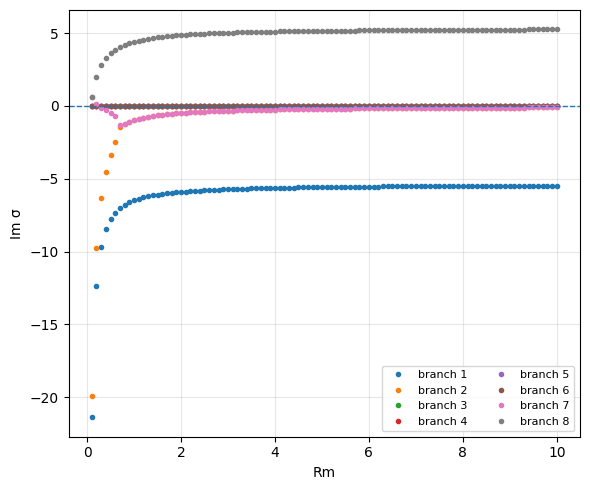

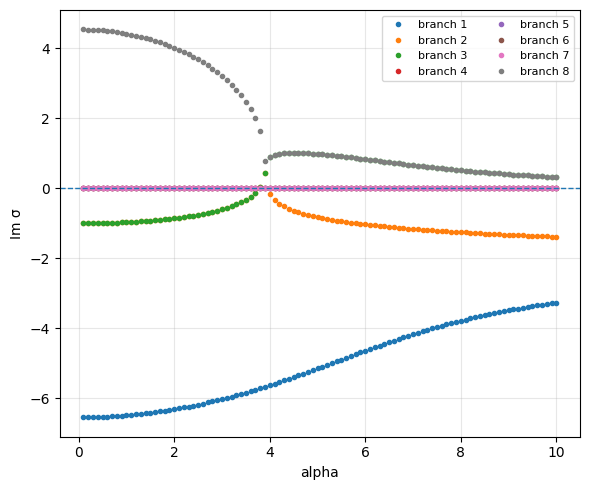

In [ ]:

if __name__ == "__main__":
    base = MHDNormalParams(
        k=1.0,
        l=1.0,
        b0x=1.0,
        b0y=1.0,
        alpha=1.0,
        mu=1.0,
        rho=1.0,
        Rm=1.0,
        H0=1.0,
        g=9.8,
        Z0=1.0,
        p0=1.0,
        b0z_const=1.0,
        A_xi=1.0 + 0.0j,
        B_normal=0.0 + 0.0j,
        Bn0_amp=0.0 + 0.0j,
    )

    roots_all, sigma_star, amps = analyze_case(base, backend="numpy", branch="max_imag")

    # отдельные дисперсионные кривые
    xs, br = sweep(base, "k", np.linspace(0.1, 10, 100))
    plot_branches(xs, br, part="imag", xlabel="k")
    plt.show()

    xs, br = sweep(base, "Rm", np.linspace(0.1, 10, 100))
    plot_branches(xs, br, part="imag", xlabel="Rm")
    plt.show()

    xs, br = sweep(base, "alpha", np.linspace(0.1, 10, 100))
    plot_branches(xs, br, part="imag", xlabel="alpha")
    plt.show()

## Дисперсионные кривые для $\tilde{B} \neq 0$

=== Исходные параметры: normal-field case ===
k                  = 1.0
l                  = 1.0
b0x                = 1.0
b0y                = 1.0
alpha              = 1.0
mu                 = 1.0
rho                = 1.0
Rm                 = 1.0
H0                 = 1.0
g                  = 9.8
Z0                 = 1.0
p0                 = 1.0
b0z_const          = 1.0
b0_pressure_abs2   = None
A_xi               = (1+0j)
B_normal           = (100+0j)
Bn0_amp            = 0j

=== Производные параметры ===
omega = alpha/2              = 0.5
K2 = k^2 + l^2               = 2.0
K = sqrt(K2)                 = 1.4142135623730951
M = b0x*k + b0y*l            = 2.0
mu*rho                       = 1.0
hB0 = H0 + Z0                = 2.0
default |b0|^2               = 3.0
M/sqrt(mu*rho)               = 2.0
K2/Rm                        = 2.0

P(sigma) degree = 8
sigma^ 8: +2.040816326531e-01 +0.000000000000e+00i
sigma^ 7: +0.000000000000e+00 +8.163265306122e-01i
sigma^ 6: +4.204081632653e+00 +0.0000

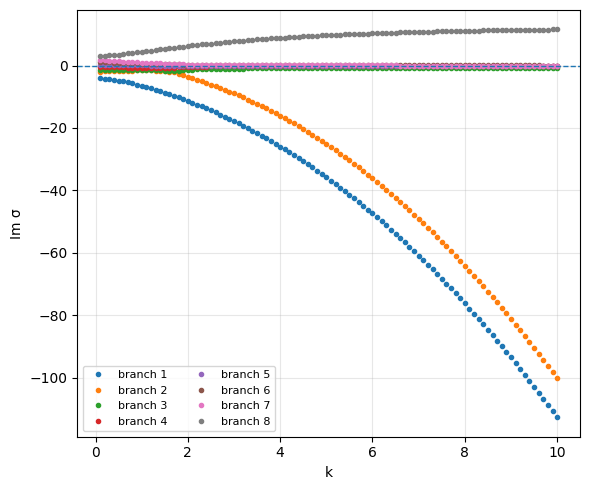

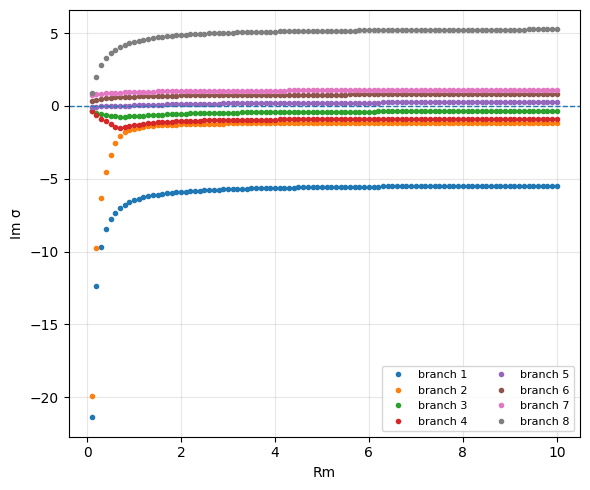

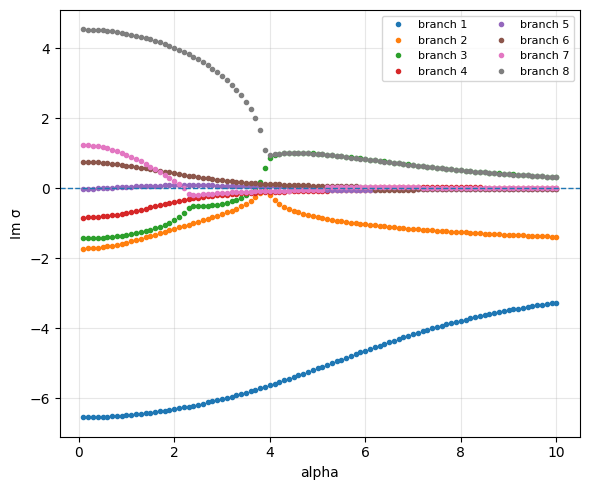

In [ ]:

if __name__ == "__main__":
    base = MHDNormalParams(
        k=1.0,
        l=1.0,
        b0x=1.0,
        b0y=1.0,
        alpha=1.0,
        mu=1.0,
        rho=1.0,
        Rm=1.0,
        H0=1.0,
        g=9.8,
        Z0=1.0,
        p0=1.0,
        b0z_const=1.0,
        A_xi=1.0 + 0.0j,
        B_normal=100.0 + 0.0j,
        Bn0_amp=0.0 + 0.0j,
    )

    roots_all, sigma_star, amps = analyze_case(base, backend="numpy", branch="max_imag")

    # отдельные дисперсионные кривые
    xs, br = sweep(base, "k", np.linspace(0.1, 10, 100))
    plot_branches(xs, br, part="imag", xlabel="k")
    plt.show()

    xs, br = sweep(base, "Rm", np.linspace(0.1, 10, 100))
    plot_branches(xs, br, part="imag", xlabel="Rm")
    plt.show()

    xs, br = sweep(base, "alpha", np.linspace(0.1, 10, 100))
    plot_branches(xs, br, part="imag", xlabel="alpha")
    plt.show()

# Колебание стенки

In [ ]:
"""
MHD forced waves from oscillating boundary.

Задача:
    x > 0,
    xi(0,t) = A0 exp(-i omega t),
    xi(x,t) = A exp(i(a x - omega t)),

где omega задается внешним воздействием, а комплексное волновое число

    a = a_re + i a_im

находится из пространственного дисперсионного уравнения.

Физический критерий для полуплоскости x>0:
    a_im > 0,
так как
    exp(i(a x - omega t)) = exp(-a_im x) exp(i(a_re x - omega t)).

Модуль строит графики, которые нужны для главы:
1) lambda(omega), delta(omega) при B0=0;
2) lambda(Rm), delta(Rm) при B0=0;
3) ветви Re a_j(omega), Im a_j(omega) при B0 != 0;
4) lambda_j(omega), delta_j(omega) для физических ветвей a_im>0;
5) профили xi(x,t0) при нескольких B0;
6) карту xi(x,t) для выбранного режима.
"""

from __future__ import annotations

from dataclasses import dataclass, replace, asdict
from typing import Iterable, Literal
import numpy as np
import matplotlib.pyplot as plt

ArrayLike = Iterable[float]
BranchChoice = Literal["least_damped", "most_damped", "largest_re", "first"]


# =============================================================================
# 1. Параметры задачи
# =============================================================================

@dataclass(frozen=True)
class WallWaveParams:
    # физические параметры
    b0x: float = 1.0
    alpha: float = 1.0
    mu: float = 1.0
    rho: float = 1.0
    Rm: float = 1.0
    H0: float = 1.0

    # внешнее воздействие
    omega: float = 1.0
    A0: complex = 1.0 + 0.0j
    B0: complex = 0.0 + 0.0j

    # технические параметры
    resonance_tol: float = 1e-10

    @property
    def murho(self) -> float:
        return self.mu * self.rho

    @property
    def cA2(self) -> float:
        return self.b0x**2 / self.murho

    @property
    def cA(self) -> float:
        return abs(self.b0x) / np.sqrt(self.murho)

    @property
    def phi(self) -> float:
        return self.omega / self.Rm

    @property
    def is_resonant(self) -> bool:
        return abs(self.alpha**2 - self.omega**2) < self.resonance_tol

    def with_(self, **kwargs) -> "WallWaveParams":
        return replace(self, **kwargs)

    def as_dict(self) -> dict:
        return asdict(self)

    def derived_dict(self) -> dict:
        return {
            "mu*rho": self.murho,
            "c_A^2 = b0x^2/(mu*rho)": self.cA2,
            "c_A": self.cA,
            "phi = omega/Rm": self.phi,
            "alpha^2 - omega^2": self.alpha**2 - self.omega**2,
            "resonance omega^2=alpha^2": self.is_resonant,
        }

    def print_report(self) -> None:
        print("=== Исходные параметры forced wall-wave case ===")
        for key, value in self.as_dict().items():
            print(f"{key:16s} = {value}")

        print("\n=== Производные параметры ===")
        for key, value in self.derived_dict().items():
            print(f"{key:32s} = {value}")


# =============================================================================
# 2. Аналитическая ветвь при B0 = 0
# =============================================================================

def equal_field_a2(p: WallWaveParams) -> complex:
    """
    Для B0=0 основная ветвь задается уравнением

        (c_A^2 - i omega/Rm) a^2 = omega^2.

    Поэтому
        a^2 = omega^2 / (c_A^2 - i omega/Rm).
    """
    return p.omega**2 / (p.cA2 - 1j * p.omega / p.Rm)


def equal_field_branches(p: WallWaveParams) -> np.ndarray:
    """Две распространяющиеся ветви a = +-sqrt(a2)."""
    a = np.sqrt(equal_field_a2(p) + 0j)
    return np.array([a, -a], dtype=complex)


def physical_equal_branch(p: WallWaveParams, prefer_positive_re: bool = True) -> complex:
    """
    Выбор физической ветви при B0=0.

    Требуется Im(a)>0. Если обе ветви имеют противоположные Im, выбираем
    затухающую. Дополнительно можно потребовать Re(a)>0 для волны с фазой,
    распространяющейся в направлении x>0.
    """
    branches = equal_field_branches(p)
    candidates = [z for z in branches if z.imag > 0]
    if not candidates:
        candidates = list(branches)

    if prefer_positive_re:
        positive = [z for z in candidates if z.real >= 0]
        if positive:
            return positive[0]

    return candidates[0]


def equal_field_are_aim(p: WallWaveParams) -> tuple[float, float]:
    """Явные формулы для a_re и a_im из текста главы."""
    omega = p.omega
    cA2 = p.cA2
    phi = p.omega / p.Rm
    denom = cA2**2 + phi**2
    root = np.sqrt(cA2**2 + phi**2)

    a_re = abs(omega) * np.sqrt((root + cA2) / (2.0 * denom))
    a_im = abs(omega) * np.sqrt((root - cA2) / (2.0 * denom))

    # знак Re удобно связать со знаком omega; Im всегда положительная
    if omega < 0:
        a_re = -a_re
    return float(a_re), float(a_im)


def wavelength_from_a(a: complex, eps: float = 1e-14) -> float:
    """lambda = 2*pi/|Re(a)|. Если Re(a) почти ноль, возвращается inf."""
    if abs(a.real) < eps:
        return np.inf
    return 2.0 * np.pi / abs(a.real)


def penetration_depth_from_a(a: complex, eps: float = 1e-14) -> float:
    """delta = 1/Im(a). Если Im(a)<=0 или почти ноль, возвращается inf/nan."""
    if abs(a.imag) < eps:
        return np.inf
    if a.imag < 0:
        return np.nan
    return 1.0 / a.imag


def equal_field_lambda_delta(p: WallWaveParams) -> tuple[float, float, complex]:
    a = physical_equal_branch(p)
    return wavelength_from_a(a), penetration_depth_from_a(a), a


def sweep_equal_by_omega(
    base: WallWaveParams,
    omega_values: ArrayLike,
) -> dict[str, np.ndarray]:
    omegas = np.asarray(list(omega_values), dtype=float)
    a_values = np.array([physical_equal_branch(base.with_(omega=w)) for w in omegas])
    lam = np.array([wavelength_from_a(a) for a in a_values])
    delta = np.array([penetration_depth_from_a(a) for a in a_values])
    return {"omega": omegas, "a": a_values, "lambda": lam, "delta": delta}


def sweep_equal_by_Rm(
    base: WallWaveParams,
    Rm_values: ArrayLike,
) -> dict[str, np.ndarray]:
    Rms = np.asarray(list(Rm_values), dtype=float)
    a_values = np.array([physical_equal_branch(base.with_(Rm=Rm)) for Rm in Rms])
    lam = np.array([wavelength_from_a(a) for a in a_values])
    delta = np.array([penetration_depth_from_a(a) for a in a_values])
    return {"Rm": Rms, "a": a_values, "lambda": lam, "delta": delta}


# =============================================================================
# 3. Уравнение пятой степени при B0 != 0
# =============================================================================

def quintic_coefficients(p: WallWaveParams) -> np.ndarray:
    """
    Коэффициенты уравнения

        (c_A^2 - i omega/Rm) a^5 - omega^2 a^3 - Q = 0,

    где
        Q = i B0 / [b0x A0 (mu*rho)^2 H0 (alpha^2 - omega^2)^2].

    Коэффициенты возвращаются для степеней a^5, a^4, ..., a^0.
    """
    if abs(p.b0x) < 1e-14:
        raise ValueError("b0x must be nonzero")
    if abs(p.A0) < 1e-14:
        raise ValueError("A0 must be nonzero")
    if p.is_resonant:
        raise ValueError("omega^2 is too close to alpha^2: resonance case requires separate analysis")

    q = 1j * p.B0 / (
        p.b0x * p.A0 * p.murho**2 * p.H0 * (p.alpha**2 - p.omega**2) ** 2
    )

    c5 = p.cA2 - 1j * p.omega / p.Rm
    c3 = -p.omega**2
    c0 = -q

    return np.array([c5, 0.0 + 0.0j, c3, 0.0 + 0.0j, 0.0 + 0.0j, c0], dtype=complex)


def wall_dispersion_roots(p: WallWaveParams) -> np.ndarray:
    """
    Корни по a.

    B0=0:
        полное уравнение имеет вид
        [(c_A^2 - i omega/Rm)a^2 - omega^2] a^3 = 0,
        поэтому есть 5 корней:
            a = 0 кратности 3,
            a = +-sqrt(omega^2 / (c_A^2 - i omega/Rm)).

    B0!=0:
        решается уравнение пятой степени.
    """
    if abs(p.B0) < 1e-14:
        a = np.sqrt(equal_field_a2(p) + 0j)
        return np.array(
            [
                0.0 + 0.0j,
                0.0 + 0.0j,
                0.0 + 0.0j,
                a,
                -a,
            ],
            dtype=complex,
        )

    return np.roots(quintic_coefficients(p))


def sort_a_roots_single(roots_array: np.ndarray) -> np.ndarray:
    """
    Удобная сортировка корней a:
    сначала физические ветви с Im(a)>0, затем остальные.
    """
    return np.asarray(
        sorted(roots_array, key=lambda z: (z.imag <= 0, abs(z.imag), z.real)),
        dtype=complex,
    )


def physical_roots(roots_array: np.ndarray, tol: float = 1e-10) -> np.ndarray:
    """Физические корни для x>0: Im(a)>0."""
    r = np.asarray(roots_array, dtype=complex)
    return r[r.imag > tol]


def match_roots_by_continuation(prev: np.ndarray, cur: np.ndarray) -> np.ndarray:
    prev = np.asarray(prev, dtype=complex)
    cur_list = list(np.asarray(cur, dtype=complex))
    matched = []
    for z in prev:
        j = int(np.argmin([abs(w - z) for w in cur_list]))
        matched.append(cur_list.pop(j))
    return np.asarray(matched, dtype=complex)

def sweep_a_roots(
    base: WallWaveParams,
    name: Literal["omega", "Rm"],
    values: ArrayLike,
) -> dict[str, np.ndarray]:
    xs = np.asarray(list(values), dtype=float)
    branches = []

    for i, value in enumerate(xs):
        p = base.with_(**{name: float(value)})
        r = wall_dispersion_roots(p)

        if i == 0:
            r = sort_a_roots_single(r)
        else:
            r = match_roots_by_continuation(branches[-1], r)

        branches.append(r)

    a = np.vstack(branches)

    return {
        name: xs,
        "a": a,
        "a_re": a.real,
        "a_im": a.imag,
    }

def sweep_quintic_by_omega(
    base: WallWaveParams,
    omega_values: ArrayLike,
) -> dict[str, np.ndarray]:
    omegas = np.asarray(list(omega_values), dtype=float)
    branches = []

    for i, w in enumerate(omegas):
        p = base.with_(omega=float(w))
        r = wall_dispersion_roots(p)
        r = sort_a_roots_single(r) if i == 0 else match_roots_by_continuation(branches[-1], r)
        branches.append(r)

    branches = np.vstack(branches)
    lam = np.full(branches.shape, np.nan)
    delta = np.full(branches.shape, np.nan)

    for i in range(branches.shape[0]):
        for j in range(branches.shape[1]):
            a = branches[i, j]
            if a.imag > 0:
                lam[i, j] = wavelength_from_a(a)
                delta[i, j] = penetration_depth_from_a(a)

    return {"omega": omegas, "a": branches, "lambda": lam, "delta": delta}


def sweep_quintic_by_Rm(
    base: WallWaveParams,
    Rm_values: ArrayLike,
) -> dict[str, np.ndarray]:
    Rms = np.asarray(list(Rm_values), dtype=float)
    branches = []

    for i, Rm in enumerate(Rms):
        p = base.with_(Rm=float(Rm))
        r = wall_dispersion_roots(p)
        r = sort_a_roots_single(r) if i == 0 else match_roots_by_continuation(branches[-1], r)
        branches.append(r)

    branches = np.vstack(branches)
    lam = np.full(branches.shape, np.nan)
    delta = np.full(branches.shape, np.nan)

    for i in range(branches.shape[0]):
        for j in range(branches.shape[1]):
            a = branches[i, j]
            if a.imag > 0:
                lam[i, j] = wavelength_from_a(a)
                delta[i, j] = penetration_depth_from_a(a)

    return {"Rm": Rms, "a": branches, "lambda": lam, "delta": delta}


# =============================================================================
# 4. Выбор ветви и профили xi
# =============================================================================

def choose_physical_branch(
    roots_array: np.ndarray,
    choice: BranchChoice = "least_damped",
    tol: float = 1e-10,
) -> complex:
    phys = physical_roots(roots_array, tol=tol)
    if len(phys) == 0:
        raise ValueError("No roots with Im(a)>0. Check parameters or sign convention.")

    if choice == "least_damped":
        return phys[int(np.argmin(phys.imag))]
    if choice == "most_damped":
        return phys[int(np.argmax(phys.imag))]
    if choice == "largest_re":
        return phys[int(np.argmax(np.abs(phys.real)))]
    if choice == "first":
        return phys[0]
    raise ValueError("unknown branch choice")


def xi_complex(
    x,
    t,
    a: complex,
    p: WallWaveParams,
    amplitude: complex | None = None,
):
    """Комплексная гармоника xi=A exp(i(a x - omega t))."""
    if amplitude is None:
        amplitude = p.A0
    return amplitude * np.exp(1j * (a * x - p.omega * t))


def xi_real(
    x,
    t,
    a: complex,
    p: WallWaveParams,
    amplitude: complex | None = None,
):
    return np.real(xi_complex(x, t, a, p, amplitude=amplitude))


def xi_profile_for_B0(
    base: WallWaveParams,
    B0: complex,
    x_values: ArrayLike,
    t0: float = 0.0,
    branch: BranchChoice = "least_damped",
) -> tuple[np.ndarray, np.ndarray, complex]:
    p = base.with_(B0=B0)
    roots = wall_dispersion_roots(p)
    a = choose_physical_branch(roots, choice=branch)
    xs = np.asarray(list(x_values), dtype=float)
    xi = xi_real(xs, t0, a, p)
    return xs, xi, a


# =============================================================================
# 5. Графики для текста главы
# =============================================================================

def plot_lambda_delta_vs_omega_equal(
    base: WallWaveParams,
    omega_values: ArrayLike,
):
    """[РИСУНОК] зависимости lambda(omega) и delta(omega) при B0=0."""
    data = sweep_equal_by_omega(base.with_(B0=0.0 + 0.0j), omega_values)
    omega = data["omega"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    axes[0].plot(omega, data["lambda"], lw=2)
    axes[0].set_xlabel(r"$\omega$")
    axes[0].set_ylabel(r"$\lambda$")
    axes[0].set_title(r"Длина волны $\lambda(\omega)$")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(omega, data["delta"], lw=2)
    axes[1].set_xlabel(r"$\omega$")
    axes[1].set_ylabel(r"$\delta$")
    axes[1].set_title(r"Глубина проникновения $\delta(\omega)$")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    return fig, axes, data


def plot_lambda_delta_vs_Rm_equal(
    base: WallWaveParams,
    Rm_values: ArrayLike,
):
    """[РИСУНОК] зависимости lambda(Rm) и delta(Rm) при B0=0."""
    data = sweep_equal_by_Rm(base.with_(B0=0.0 + 0.0j), Rm_values)
    Rm = data["Rm"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    axes[0].plot(Rm, data["lambda"], lw=2)
    axes[0].set_xlabel(r"$R_m$")
    axes[0].set_ylabel(r"$\lambda$")
    axes[0].set_title(r"Длина волны $\lambda(R_m)$")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(Rm, data["delta"], lw=2)
    axes[1].set_xlabel(r"$R_m$")
    axes[1].set_ylabel(r"$\delta$")
    axes[1].set_title(r"Глубина проникновения $\delta(R_m)$")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    return fig, axes, data


def plot_a_branches_vs_omega_nonequal(
    base: WallWaveParams,
    omega_values: ArrayLike,
):
    """[РИСУНОК] ветви Re a_j(omega), Im a_j(omega) при B0 != 0."""
    data = sweep_quintic_by_omega(base, omega_values)
    omega = data["omega"]
    a = data["a"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for j in range(a.shape[1]):
        axes[0].plot(omega, a[:, j].real, ".", ms=4, label=f"branch {j+1}")
        axes[1].plot(omega, a[:, j].imag, ".", ms=4, label=f"branch {j+1}")

    axes[0].axhline(0.0, lw=1.0, ls="--")
    axes[0].set_xlabel(r"$\omega$")
    axes[0].set_ylabel(r"$\operatorname{Re} a$")
    axes[0].set_title(r"Вещественные части $a_j$")
    axes[0].grid(True, alpha=0.3)

    axes[1].axhline(0.0, lw=1.0, ls="--")
    axes[1].set_xlabel(r"$\omega$")
    axes[1].set_ylabel(r"$\operatorname{Im} a$")
    axes[1].set_title(r"Мнимые части $a_j$")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(ncol=2, fontsize=8)

    fig.tight_layout()
    return fig, axes, data

def plot_a_branches_vs_Rm_nonequal(
    base: WallWaveParams,
    Rm_values: ArrayLike,
):
    """[РИСУНОК] ветви Re a_j(Rm), Im a_j(Rm) при B0 != 0."""
    data = sweep_quintic_by_Rm(base, Rm_values)
    Rm = data["Rm"]
    a = data["a"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    for j in range(a.shape[1]):
        axes[0].plot(Rm, a[:, j].real, ".", ms=4, label=f"branch {j+1}")
        axes[1].plot(Rm, a[:, j].imag, ".", ms=4, label=f"branch {j+1}")

    axes[0].axhline(0.0, lw=1.0, ls="--")
    axes[0].set_xlabel(r"$R_m$")
    axes[0].set_ylabel(r"$\operatorname{Re} a$")
    axes[0].set_title(r"Вещественные части $a_j$")
    axes[0].grid(True, alpha=0.3)

    axes[1].axhline(0.0, lw=1.0, ls="--")
    axes[1].set_xlabel(r"$R_m$")
    axes[1].set_ylabel(r"$\operatorname{Im} a$")
    axes[1].set_title(r"Мнимые части $a_j$")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(ncol=2, fontsize=8)

    fig.tight_layout()
    return fig, axes, data


def plot_lambda_delta_vs_omega_nonequal(
    base: WallWaveParams,
    omega_values: ArrayLike,
):
    """[РИСУНОК] lambda_j(omega), delta_j(omega) для ветвей с Im(a)>0."""
    data = sweep_quintic_by_omega(base, omega_values)
    omega = data["omega"]
    lam = data["lambda"]
    delta = data["delta"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    for j in range(lam.shape[1]):
        axes[0].plot(omega, lam[:, j], ".", ms=4, label=f"branch {j+1}")
        axes[1].plot(omega, delta[:, j], ".", ms=4, label=f"branch {j+1}")

    axes[0].set_xlabel(r"$\omega$")
    axes[0].set_ylabel(r"$\lambda_j$")
    axes[0].set_title(r"Длины волн физических ветвей")
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel(r"$\omega$")
    axes[1].set_ylabel(r"$\delta_j$")
    axes[1].set_title(r"Глубины проникновения физических ветвей")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(ncol=2, fontsize=8)

    fig.tight_layout()
    return fig, axes, data


def plot_xi_profiles_for_B0(
    base: WallWaveParams,
    B0_values: ArrayLike,
    x_values: ArrayLike,
    t0: float = 0.0,
    branch: BranchChoice = "least_damped",
):
    """[РИСУНОК] профили xi(x,t0) при нескольких B0."""
    xs = np.asarray(list(x_values), dtype=float)

    fig, ax = plt.subplots(figsize=(8, 4.8))
    used = []
    for B0 in B0_values:
        x, xi, a = xi_profile_for_B0(base, complex(B0), xs, t0=t0, branch=branch)
        ax.plot(x, xi, lw=2, label=fr"$B_0={B0:g}$, $a={a.real:.3g}+{a.imag:.3g}i$")
        used.append((B0, a))

    ax.axhline(0.0, lw=1.0, ls="--")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$\xi(x,t_0)$")
    ax.set_title(fr"Профили $\xi(x,t_0)$, $t_0={t0:g}$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    return fig, ax, used


def plot_lambda_delta_vs_B0(
    base: WallWaveParams,
    B0_values: ArrayLike,
    branch: BranchChoice = "least_damped",
):
    """
    Зависимости lambda(B0) и delta(B0)
    для выбранной физической ветви.
    """

    B0_values = np.asarray(list(B0_values), dtype=float)

    lambda_values = []
    delta_values = []
    used_roots = []

    for B0 in B0_values:

        p = base.with_(B0=complex(B0))

        roots = wall_dispersion_roots(p)

        try:
            a = choose_physical_branch(roots, choice=branch)

            lam = wavelength_from_a(a)
            delta = penetration_depth_from_a(a)

        except ValueError:
            a = np.nan + 1j * np.nan
            lam = np.nan
            delta = np.nan

        lambda_values.append(lam)
        delta_values.append(delta)
        used_roots.append(a)

    lambda_values = np.asarray(lambda_values)
    delta_values = np.asarray(delta_values)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].plot(B0_values, lambda_values, lw=2)
    axes[0].set_xlabel(r"$B_0$")
    axes[0].set_ylabel(r"$\lambda$")
    axes[0].set_title(r"Длина волны $\lambda(B_0)$")

    axes[1].plot(B0_values, delta_values, lw=2)
    axes[1].set_xlabel(r"$B_0$")
    axes[1].set_ylabel(r"$\delta$")
    axes[1].set_title(r"Глубина проникновения $\delta(B_0)$")

    for ax in axes:
        ax.grid(True, alpha=0.3)

    fig.tight_layout()

    return fig, axes, {
        "B0": B0_values,
        "lambda": lambda_values,
        "delta": delta_values,
        "roots": np.asarray(used_roots),
    }

def plot_xi_xt_map(
    p: WallWaveParams,
    a: complex | None = None,
    xlim: tuple[float, float] = (0.0, 20.0),
    tlim: tuple[float, float] = (0.0, 20.0),
    nx: int = 250,
    nt: int = 180,
    branch: BranchChoice = "least_damped",
):
    """Дополнительная карта xi(x,t), полезна для презентации/проверки."""
    if a is None:
        a = choose_physical_branch(wall_dispersion_roots(p), choice=branch)

    xs = np.linspace(*xlim, nx)
    ts = np.linspace(*tlim, nt)
    X, T = np.meshgrid(xs, ts)
    XI = xi_real(X, T, a, p)

    fig, ax = plt.subplots(figsize=(8, 4.8))
    im = ax.pcolormesh(X, T, XI, shading="auto")
    fig.colorbar(im, ax=ax, label=r"$\xi$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$t$")
    ax.set_title(fr"$\xi(x,t)$, $a={a.real:.3g}+{a.imag:.3g}i$")
    fig.tight_layout()
    return fig, ax, a

def plot_im_a_branches(
    base: WallWaveParams,
    name: Literal["omega", "Rm"],
    values: ArrayLike,
):
    """
    Рисует только Im(a_j) для всех ветвей.

    Для B0=0 будут видны:
        три нулевые ветви a=0,
        две ветви +-sqrt(...).

    Для B0!=0 будут видны пять корней уравнения пятой степени.
    """
    data = sweep_a_roots(base, name, values)

    x = data[name]
    a = data["a"]

    xlabel = r"$\omega$" if name == "omega" else r"$R_m$"

    fig, ax = plt.subplots(figsize=(7, 5))

    for j in range(a.shape[1]):
        a0 = a[0, j]
        label = fr"$a_{j+1}$: {a0.real:.2f}{a0.imag:+.2f}i$"
        ax.plot(x, a[:, j].imag, ".", ms=4, label=label)

    ax.axhline(0.0, lw=1.0, ls="--")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$\operatorname{Im} a_j$")
    ax.set_title(r"Дисперсионные ветви $\operatorname{Im} a_j$")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

    fig.tight_layout()
    return fig, ax, data


# =============================================================================
# 6. Полный быстрый отчет
# =============================================================================

def print_roots_report(p: WallWaveParams) -> np.ndarray:
    p.print_report()
    print()
    if abs(p.B0) < 1e-14:
        roots = equal_field_branches(p)
        print("=== B0=0: основные ветви a ===")
    else:
        coeffs = quintic_coefficients(p)
        print("=== B0!=0: коэффициенты quintic по a ===")
        degree = len(coeffs) - 1
        for i, c in enumerate(coeffs):
            power = degree - i
            print(f"a^{power}: {c.real:+.12e} {c.imag:+.12e}i")
        roots = wall_dispersion_roots(p)
        print("\n=== Корни a ===")

    roots = sort_a_roots_single(roots)
    for j, a in enumerate(roots, start=1):
        status = "физическая, затухающая" if a.imag > 0 else "не подходит для x>0"
        lam = wavelength_from_a(a)
        delta = penetration_depth_from_a(a)
        print(
            f"{j:2d}: a = {a.real:+.10e} {a.imag:+.10e}i, "
            f"lambda={lam:.6g}, delta={delta:.6g}   ({status})"
        )
    return roots

=== Исходные параметры forced wall-wave case ===
b0x              = 1.0
alpha            = 4.0
mu               = 1.0
rho              = 1.0
Rm               = 1.0
H0               = 1.0
omega            = 2.0
A0               = (0.01+0j)
B0               = 0j
resonance_tol    = 1e-10

=== Производные параметры ===
mu*rho                           = 1.0
c_A^2 = b0x^2/(mu*rho)           = 1.0
c_A                              = 1.0
phi = omega/Rm                   = 2.0
alpha^2 - omega^2                = 12.0
resonance omega^2=alpha^2        = False

=== B0=0: основные ветви a ===
 1: a = +1.1377289620e+00 +7.0315516851e-01i, lambda=5.52257, delta=1.42216   (физическая, затухающая)
 2: a = -1.1377289620e+00 -7.0315516851e-01i, lambda=5.52257, delta=nan   (не подходит для x>0)


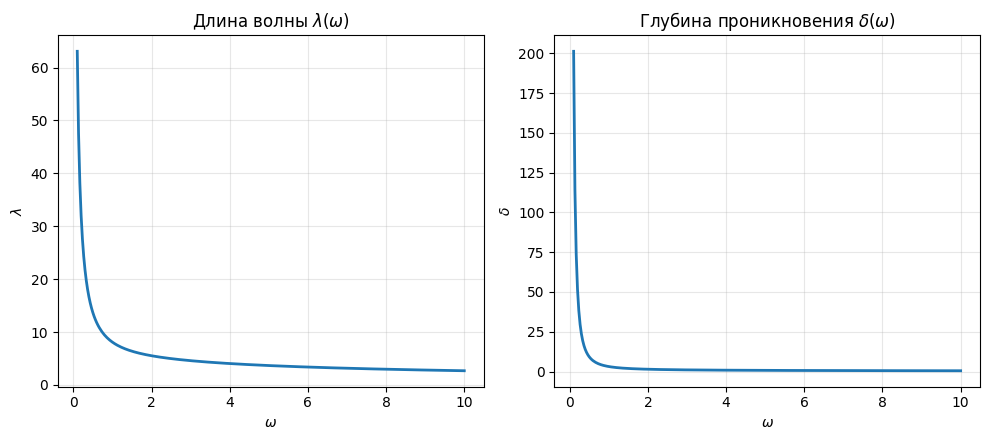

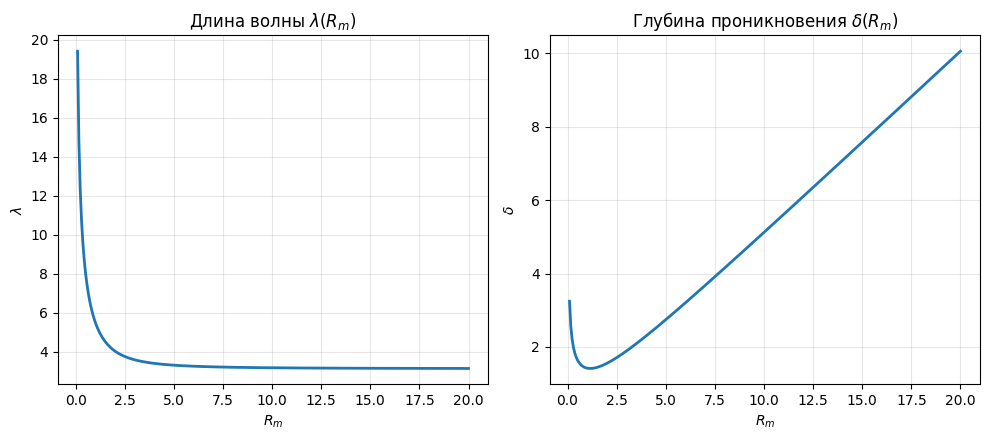

In [ ]:
if __name__ == "__main__":
    base_equal = WallWaveParams(
        b0x=1.0,
        alpha=4.0,
        mu=1.0,
        rho=1.0,
        Rm=1.0,
        H0=1.0,
        omega=2.0,
        A0=0.01 + 0.0j,
        B0=0.0 + 0.0j,
    )

    print_roots_report(base_equal)

    omega_values = np.linspace(0.1, 10.0, 300)
    plot_lambda_delta_vs_omega_equal(base_equal, omega_values)
    plt.show()

    Rm_values = np.linspace(0.1, 20.0, 300)
    plot_lambda_delta_vs_Rm_equal(base_equal, Rm_values)
    plt.show()

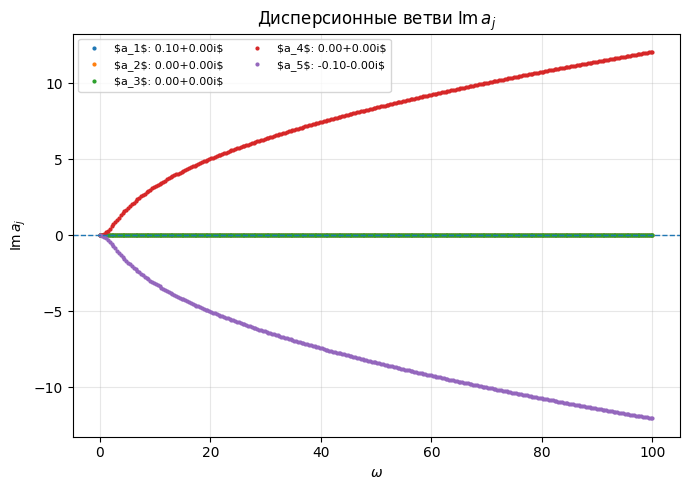

In [ ]:
base_equal = WallWaveParams(
    b0x=1,
    alpha=1,
    mu=1,
    rho=1,
    Rm=3,
    H0=1,
    omega=2,
    A0=1,
    B0=0,
)

omega_values = np.linspace(0.1, 100, 300)

plot_im_a_branches(base_equal, "omega", omega_values)
plt.show()

=== Исходные параметры forced wall-wave case ===
b0x              = 1.0
alpha            = 4.0
mu               = 1.0
rho              = 1.0
Rm               = 1.0
H0               = 1.0
omega            = 2.0
A0               = (0.01+0j)
B0               = 0j
resonance_tol    = 1e-10

=== Производные параметры ===
mu*rho                           = 1.0
c_A^2 = b0x^2/(mu*rho)           = 1.0
c_A                              = 1.0
phi = omega/Rm                   = 2.0
alpha^2 - omega^2                = 12.0
resonance omega^2=alpha^2        = False

=== B0=0: основные ветви a ===
 1: a = +1.1377289620e+00 +7.0315516851e-01i, lambda=5.52257, delta=1.42216   (физическая, затухающая)
 2: a = -1.1377289620e+00 -7.0315516851e-01i, lambda=5.52257, delta=nan   (не подходит для x>0)
=== Исходные параметры forced wall-wave case ===
b0x              = 1.0
alpha            = 4.0
mu               = 1.0
rho              = 1.0
Rm               = 1.0
H0               = 1.0
omega            = 2.0
A0   

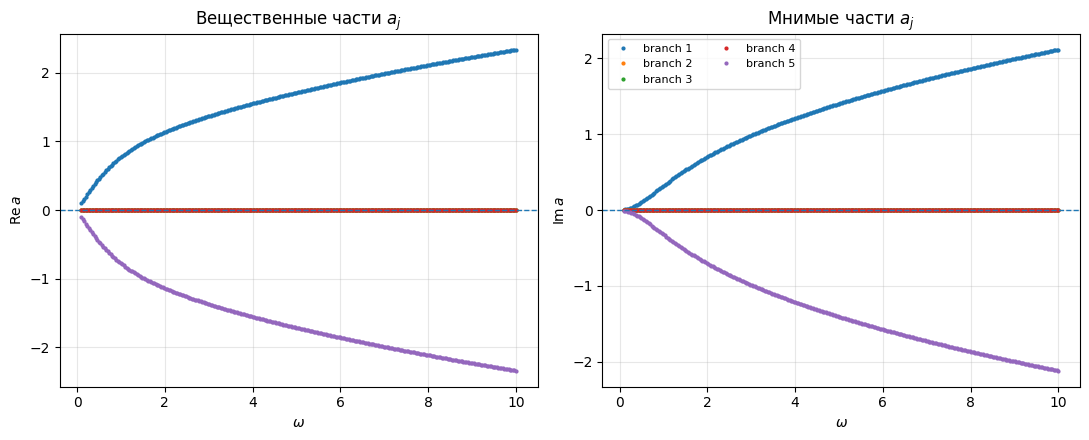

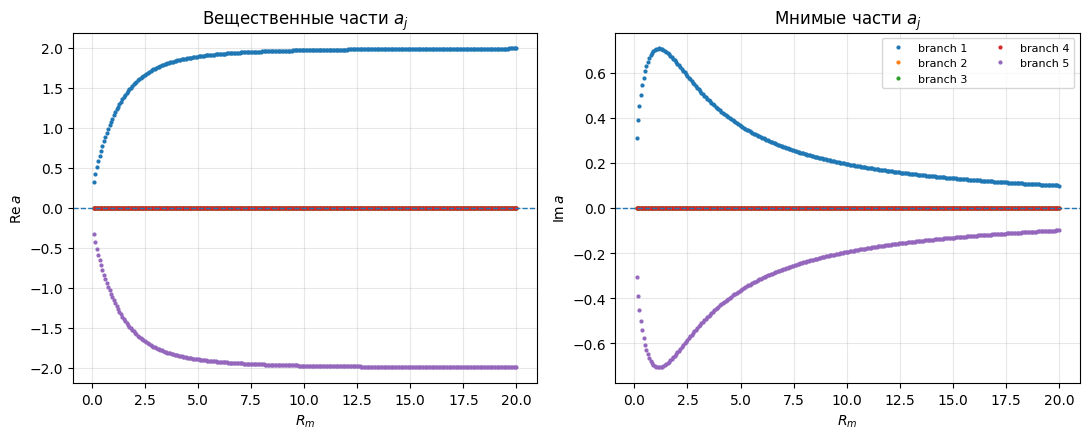

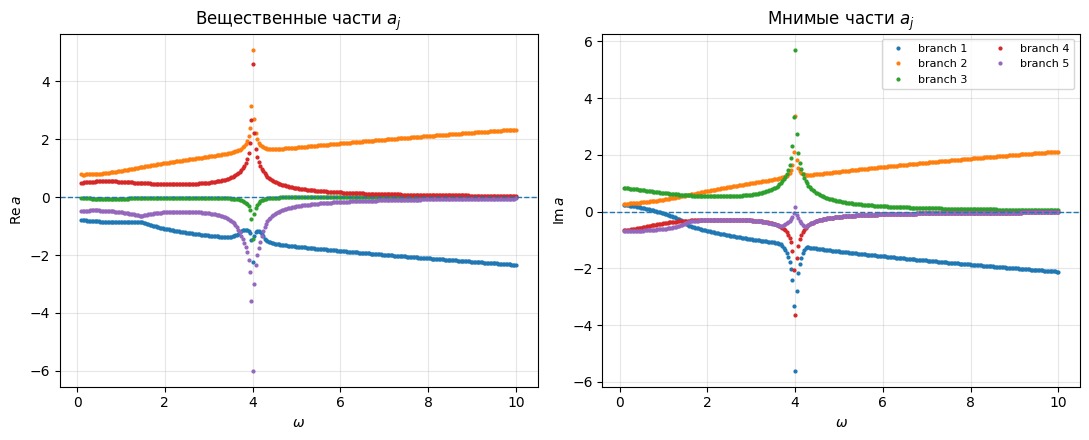

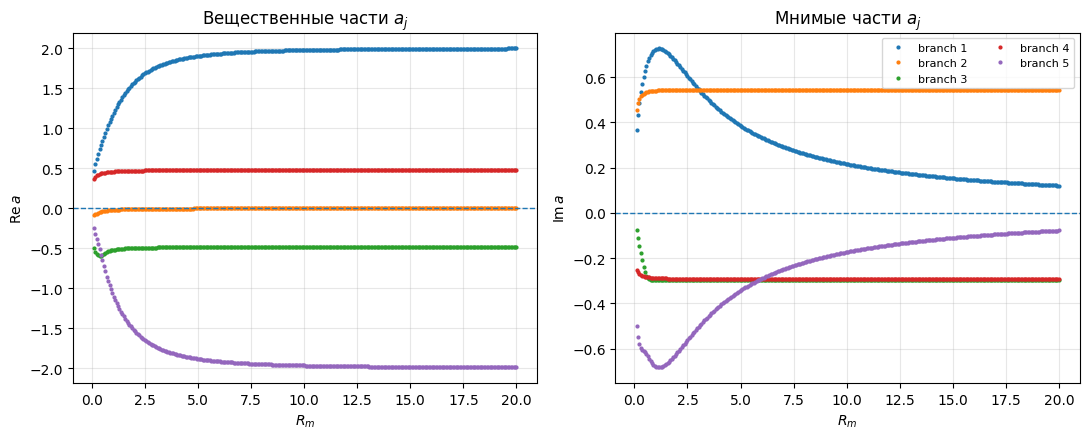

In [ ]:
if __name__ == "__main__":
    base_equal = WallWaveParams(
        b0x=1.0,
        alpha=4.0,
        mu=1.0,
        rho=1.0,
        Rm=1.0,
        H0=1.0,
        omega=2.0,
        A0=0.01 + 0.0j,
        B0=0.0 + 0.0j,
    )

    print_roots_report(base_equal)
    base_nonequal = base_equal.with_(B0=1.0 + 0.0j, omega=2.0)
    print_roots_report(base_nonequal)

    omega_values = np.linspace(0.1, 10.0, 300)
    Rm_values = np.linspace(0.1, 20.0, 300)

    # omega
    plot_a_branches_vs_omega_nonequal(base_equal, omega_values)
    plot_a_branches_vs_Rm_nonequal(base_equal, Rm_values)
    plt.show()

    # Rm
    plot_a_branches_vs_omega_nonequal(base_nonequal, omega_values)
    plot_a_branches_vs_Rm_nonequal(base_nonequal, Rm_values)
    plt.show()

=== Исходные параметры forced wall-wave case ===
b0x              = 1.0
alpha            = 4.0
mu               = 1.0
rho              = 1.0
Rm               = 1.0
H0               = 1.0
omega            = 2.0
A0               = (0.01+0j)
B0               = 0j
resonance_tol    = 1e-10

=== Производные параметры ===
mu*rho                           = 1.0
c_A^2 = b0x^2/(mu*rho)           = 1.0
c_A                              = 1.0
phi = omega/Rm                   = 2.0
alpha^2 - omega^2                = 12.0
resonance omega^2=alpha^2        = False

=== B0=0: основные ветви a ===
 1: a = +1.1377289620e+00 +7.0315516851e-01i, lambda=5.52257, delta=1.42216   (физическая, затухающая)
 2: a = -1.1377289620e+00 -7.0315516851e-01i, lambda=5.52257, delta=nan   (не подходит для x>0)
=== Исходные параметры forced wall-wave case ===
b0x              = 1.0
alpha            = 4.0
mu               = 1.0
rho              = 1.0
Rm               = 1.0
H0               = 1.0
omega            = 2.0
A0   

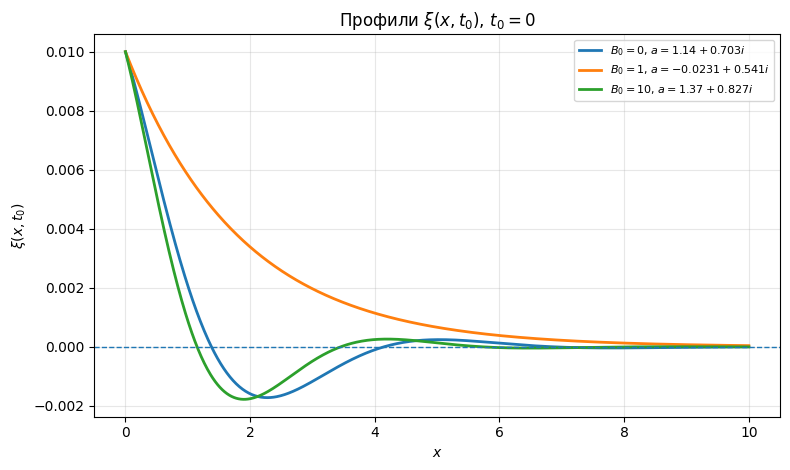

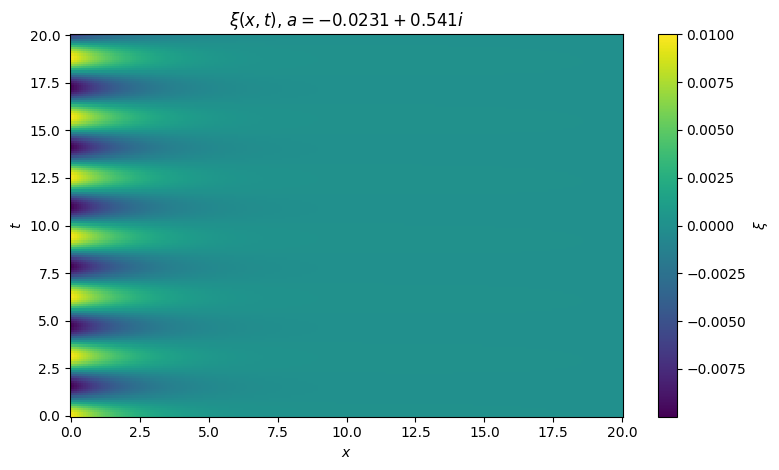

In [ ]:
if __name__ == "__main__":
    base_equal = WallWaveParams(
        b0x=1.0,
        alpha=4.0,
        mu=1.0,
        rho=1.0,
        Rm=1.0,
        H0=1.0,
        omega=2.0,
        A0=0.01 + 0.0j,
        B0=0.0 + 0.0j,
    )

    print_roots_report(base_equal)

    omega_values = np.linspace(0.1, 10.0, 300)

    base_nonequal = base_equal.with_(B0=1.0 + 0.0j, omega=2.0)
    print_roots_report(base_nonequal)

    x_values = np.linspace(0.0, 10.0, 800)
    plot_xi_profiles_for_B0(base_nonequal, B0_values=[0.0, 1.0, 10.0], x_values=x_values, t0=0.0)
    plt.show()

    plot_xi_xt_map(base_nonequal, xlim=(0, 20), tlim=(0, 20))
    plt.show()

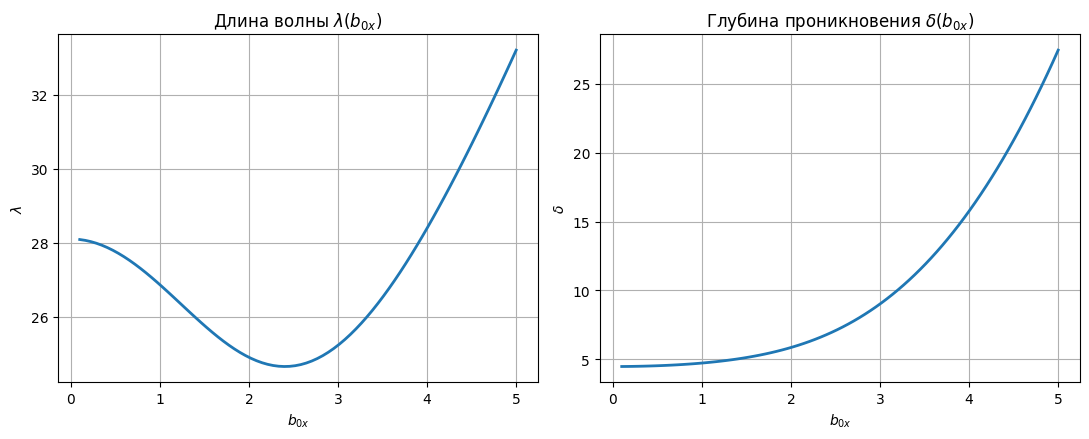

In [ ]:
    # -------------------------------------------------------------------------
    # EXPERIMENT 1
    # Влияние магнитного поля b0x
    # -------------------------------------------------------------------------

    b_values = np.linspace(0.1, 5.0, 80)

    lambda_values = []
    delta_values = []

    for b in b_values:
        p = WallWaveParams(
            b0x=b,
            omega=1.0,
            Rm=0.1,
            alpha=1.2,
            B0=1.0,
        )

        lam, delta, a = equal_field_lambda_delta(p)

        lambda_values.append(lam)
        delta_values.append(delta)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].plot(b_values, lambda_values, lw=2)
    axes[0].set_xlabel(r"$b_{0x}$")
    axes[0].set_ylabel(r"$\lambda$")
    axes[0].set_title(r"Длина волны $\lambda(b_{0x})$")

    axes[1].plot(b_values, delta_values, lw=2)
    axes[1].set_xlabel(r"$b_{0x}$")
    axes[1].set_ylabel(r"$\delta$")
    axes[1].set_title(r"Глубина проникновения $\delta(b_{0x})$")

    for ax in axes:
        ax.grid(True)

    plt.tight_layout()
    plt.show()

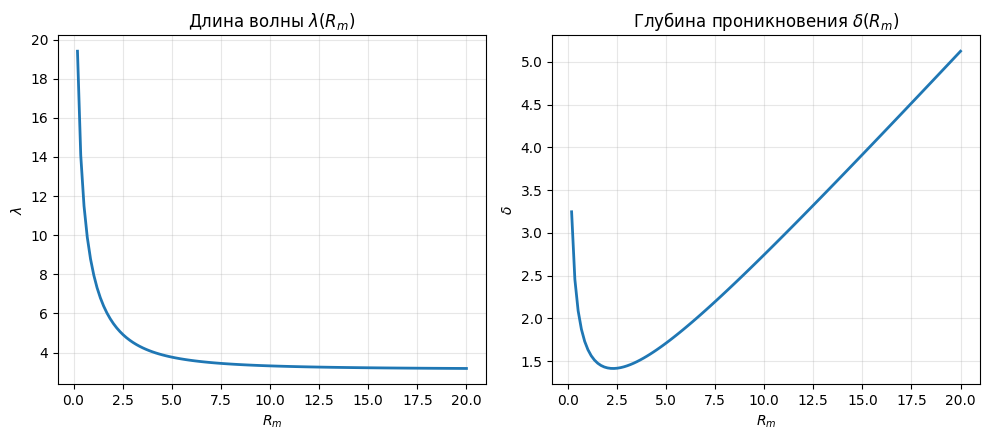

In [ ]:
    # -------------------------------------------------------------------------
    # EXPERIMENT 2
    # Влияние магнитного числа Рейнольдса
    # -------------------------------------------------------------------------

    base = WallWaveParams(
        b0x=0.5,
        omega=1.0,
        alpha=1.2,
        B0=0.0,
    )

    Rm_values = np.linspace(0.2, 20.0, 120)

    plot_lambda_delta_vs_Rm_equal(base, Rm_values)

    plt.show()

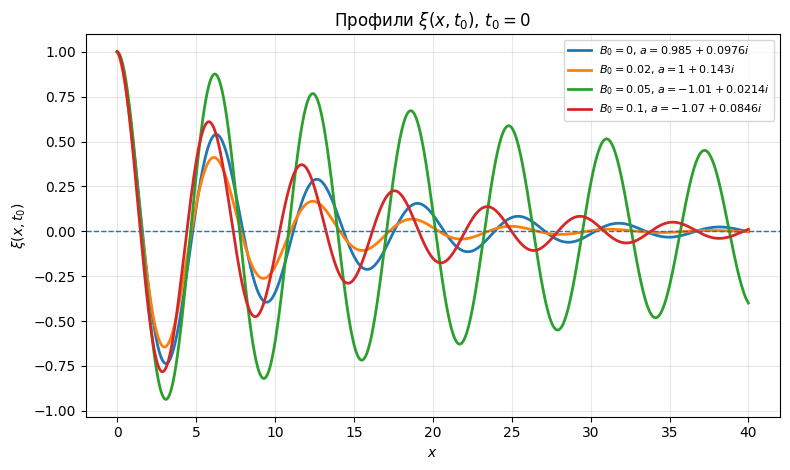

In [ ]:
    # -------------------------------------------------------------------------
    # EXPERIMENT 3
    # Профили волн при разных B0
    # -------------------------------------------------------------------------

    base = WallWaveParams(
        b0x=1.0,
        omega=1.0,
        Rm=5.0,
        alpha=1.2,
    )

    x_values = np.linspace(0, 40, 1200)

    plot_xi_profiles_for_B0(
        base=base,
        B0_values=[0.0, 0.02, 0.05, 0.1],
        x_values=x_values,
        t0=0.0,
    )

    plt.show()

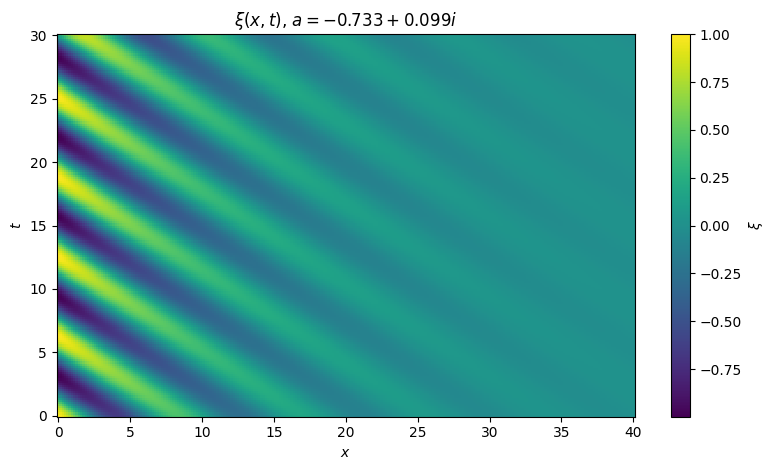

In [ ]:
    # -------------------------------------------------------------------------
    # EXPERIMENT 4
    # Карта xi(x,t)
    # -------------------------------------------------------------------------

    p = WallWaveParams(
        b0x=1.5,
        omega=1.0,
        Rm=8.0,
        alpha=1.2,
        B0=0.05,
    )

    plot_xi_xt_map(
        p,
        xlim=(0, 40),
        tlim=(0, 30),
    )

    plt.show()

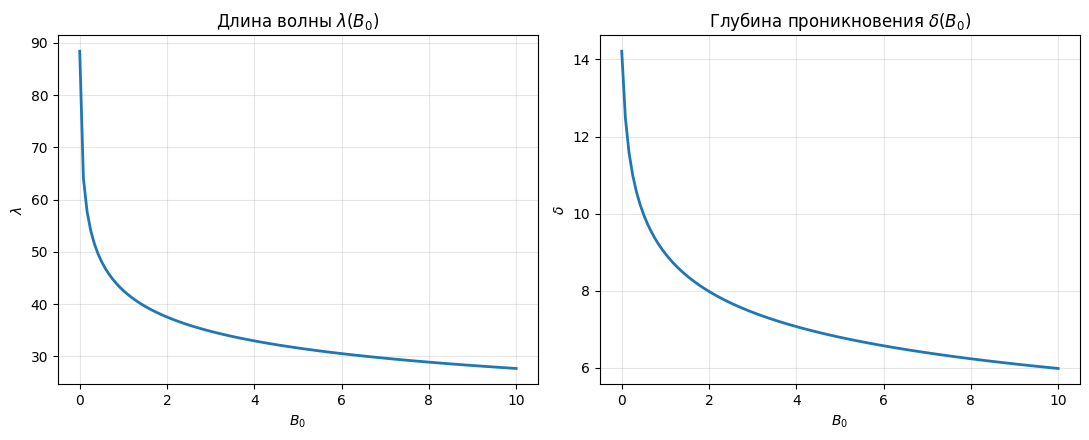

In [ ]:
# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":

    base = WallWaveParams(
        b0x=1.0,
        alpha=3.0,
        mu=1.0,
        rho=1.0,
        Rm=0.01,        # было слишком большое
        H0=1.0,
        omega=1.0,
        A0=1.0,
    )

    B0_values = np.linspace(0.0, 10.0, 120)

    plot_lambda_delta_vs_B0(
        base=base,
        B0_values=B0_values,
        branch="least_damped",
    )

    plt.show()